# LayerNorm fold vs uniform split — and the ResNet block-neuron-head-token granularity

Two independent questions, one notebook.

## Part 1 — is the uniform LayerNorm split doing damage?

Gandelsman et al. (App. A.1) linearize the final LN by freezing `sigma` and then **splitting the
input-dependent offset `mu` uniformly across all summands**. With `K = 2L+1` intermediates
(L attention layers + L MLPs + `ln_pre`) and `H` heads:

$$c^{\rm orig}_{l,h} \;=\; P\Big[\gamma\odot\big(x_{l,h}-\tfrac{\mu(x)}{KH}\mathbf 1\big)/\sigma\Big] + \tfrac{P\beta}{KH},
\qquad
c^{\rm orig}_{m} \;=\; P\Big[\gamma\odot\big(x_{m}-\tfrac{\mu(x)}{K}\mathbf 1\big)/\sigma\Big] + \tfrac{P\beta}{K}$$

But **mean-subtraction is linear**, so it does not need splitting at all. Write
$C = I - \tfrac1d\mathbf 1\mathbf 1^\top$, $D=\mathrm{diag}(\gamma/\sigma)$ and fold
$\tilde P = PDC$. Since $\mu(x)=\sum_k \mu(x_k)$, every component carries its **own** mean:

$$\boxed{\;M(I) \;=\; \sum_k \underbrace{P\Big[\gamma\odot\big(x_k-\mu(x_k)\mathbf 1\big)/\sigma\Big]}_{\tilde c_k} \;+\; \underbrace{P\beta}_{\text{unattributable bias}}\;}$$

This is the TransformerLens `center_writing_weights` / `fold_ln` treatment and the one in Ferrando
et al.'s *Primer*. Only $P\beta$ is genuinely unattributable, and it is input-independent, so it is
kept as a standalone bias term rather than smeared.

**The difference is a shared rank-1 direction.** Subtracting:

$$\delta_k \;=\; c^{\rm orig}_k-\tilde c_k \;=\; \underbrace{\frac{\mu(x_k)-\mu(x)/K_k}{\sigma(I)}}_{\alpha_k(I)\ \text{scalar, image-dependent}}\;\cdot\;(P\gamma)\;+\;\frac{P\beta}{K_k}$$

so the uniform split adds to **every** head the *same* direction $P\gamma$ with an image-varying
magnitude. That is a component with genuine cross-image variance belonging to no head in particular
— exactly what TextSpan/PCLens select on (their Eq. 7 centers, killing the constant $P\beta$ part
but **not** the $\mu$ part).

Both decompositions sum **exactly** to $M(I)$; nothing about fidelity breaks. Only per-summand
interpretation — and therefore **mean-ablation semantics** — shifts. Mean-ablating a head under the
uniform split also strips its $1/(KH)$ slice of an image-dependent *global* term, so the ablation
mixes head effect with LN offset effect. That is the hypothesis this notebook tests.

**What we run:** ViT-B-16 and ViT-L-14 on ImageNet, both conventions from a single forward pass,
then identical mean-ablation sets under both — layers (two sorting orders), MLPs, heads.

## Part 2 — the ResNet block-neuron-head-token decomposition

**Is this already the decomposition we have? Partly — the coarse end of it is.**

| index kept | in `utils/models/resnet_prs.py`? |
|---|---|
| block $k$ | **yes** — `decompose_feature_map` *is* the $G_k = G_{k+1}S_{k+1}D_k$ recursion, returning $G_kF_k(x_{k-1})$ per block |
| head $h$ | **yes** — `attnpool_split` splits the frozen-softmax pooling per head |
| token $i$ | **no** — summed inside `head_value` (`einsum("bhi,ibhd->bhd", attn, v)`) |
| neuron $n$ | **no** — $W_v$ mixes all $C$ input channels at once |

So the saved `{dataset}_attn_RN50_seed_69.npy` of shape `[N, L+1, H, out_dim]` **is** exactly
$\boldsymbol r^{h,k} = \sum_n\sum_i \boldsymbol r^{n,h,k}_i$ — the block-head view the write-up calls "the
granularity at which we operate". Part 2 builds the full four-index object, verifies it returns
`visual(I)`, and verifies it collapses onto the existing `c_lh` bit-for-bit.

---
# Part 1 — ViT

## Stage 0 — setup

In [1]:
import os
# This node caps the user cgroup at 256 pids and torch otherwise opens ~96 OMP threads, which both
# starves DataLoader forks (BlockingIOError on os.fork) and thrashes the input pipeline. Must be set
# before torch is imported.
os.environ.setdefault("OMP_NUM_THREADS", "8")
os.environ.setdefault("MKL_NUM_THREADS", "8")

import json, math, gc
import numpy as np
import torch
import tqdm
import matplotlib.pyplot as plt
from tabulate import tabulate

from utils.models.factory import create_model_and_transforms
from utils.models.prs_hook import PRSLogger
from utils.datasets.dataset_helpers import dataset_to_dataloader
from utils.misc.misc import accuracy
from torchvision.datasets import ImageNet

torch.set_grad_enabled(False)
torch.set_num_threads(8)

# ------------------------------------------------------------------ config
DEVICE      = "cuda:0" if torch.cuda.is_available() else "cpu"
SEED        = 69
DATASET     = "imagenet"
DATA_PATH   = "./datasets/"
OUT_DIR     = f"output_dir/activations_and_datasets_idxs_{SEED}"
# spc=5 / tot=50 reproduces EXACTLY the subset the saved .npy activations were computed on,
# which lets us cross-check our re-implementation of the original convention against them.
SPC, TOT    = 5, 50
BATCH       = 64
NUM_WORKERS = 4     # keep modest: the 256-pid cgroup cap is shared with every other shell/thread

MODELS = [
    ("ViT-B-16", "laion2b_s34b_b88k"),
    ("ViT-L-14", "laion2b_s32b_b82k"),
]

# two-series categorical palette (validated: CVD dE 24.7 protan / 32.7 tritan, both >= 3:1 on surface)
CLR = {"orig": "#2a78d6", "fold": "#eb6834"}
LBL = {"orig": "uniform split (Gandelsman)", "fold": "centering fold (exact)"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d3"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9, "lines.linewidth": 2.0,
})

print("device:", DEVICE)

/home/virgilio/lib/minconda3/envs/MT/lib/python3.10/site-packages/torch/cuda/__init__.py:51: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda:0


## Stage 1 — a logger that emits BOTH conventions from one forward pass

`PRSLoggerFold` subclasses the repo's `PRSLogger`; the hooks (and therefore the raw residual-stream
writes `x_k`) are untouched. Only `finalize` changes: it applies the final LN two ways to the *same*
captured tensors, so any difference downstream is attributable to the LN convention and nothing else.

Two things deliberately left alone, so they are not confounds:

- the **`attn.out_proj` bias** is still split `b_out/H` across heads by `compute_attentions_non_spatial`
  (inherited). It is input-independent and identical under both conventions.
- the final division by `||M(I)||` (which makes components sum to the L2-normalized embedding) uses
  the same per-image scalar for both, so per-image `argmax` comparisons stay fair.

In [2]:
class PRSLoggerFold(PRSLogger):
    """PRSLogger that returns BOTH final-LN conventions from a single forward pass.

    finalize_both(representation) -> dict with, for each scheme in {"orig", "fold"}:
        attn [b, L, H, d_out], mlp [b, L+1, d_out], bias [b, d_out]
    such that   attn.sum((1,2)) + mlp.sum(1) + bias  ==  representation / ||representation||.

    "orig": mu and beta split uniformly over K*H (attn) / K (mlp), K = 2L+1   <- the paper
    "fold": every component carries its OWN mean; beta kept whole as `bias`   <- the fix
    """

    @torch.no_grad()
    def finalize_both(self, representation):
        dev = self.device
        A = torch.stack(self.attentions, dim=1).to(dev, torch.float32)   # [b, L,   H, d_model]
        M = torch.stack(self.mlps, dim=1).to(dev, torch.float32)         # [b, L+1,    d_model]
        mu = self.post_ln_mean.to(dev, torch.float32)                    # [b, 1]  mean of x
        sd = self.post_ln_std.to(dev, torch.float32)                     # [b, 1]  sqrt(var+eps)

        v = self.model.visual
        g = v.ln_post.weight.detach().to(dev, torch.float32)             # gamma [d_model]
        b = v.ln_post.bias.detach().to(dev, torch.float32)               # beta  [d_model]
        P = v.proj.detach().to(dev, torch.float32)                       # [d_model, d_out]

        K = A.shape[1] + M.shape[1]        # 2L+1 == `len_intermediates` in prs_hook.py
        H = A.shape[2]

        # -- convention 1: uniform split of mu and beta (verbatim prs_hook.py algebra) ------------
        a_o = ((A - mu[:, :, None, None] / (K * H)) * g / sd[:, :, None, None] + b / (K * H)) @ P
        m_o = ((M - mu[:, :, None] / K) * g / sd[:, :, None] + b / K) @ P

        # -- convention 2: exact centering fold, beta standalone ---------------------------------
        a_f = ((A - A.mean(-1, keepdim=True)) * g / sd[:, :, None, None]) @ P
        m_f = ((M - M.mean(-1, keepdim=True)) * g / sd[:, :, None]) @ P
        bias_f = (b @ P).expand(A.shape[0], -1)

        n = representation.detach().to(dev, torch.float32).norm(dim=-1)  # [b]
        z = torch.zeros_like(bias_f)
        out = {
            "orig": {"attn": a_o / n[:, None, None, None], "mlp": m_o / n[:, None, None],
                     "bias": z},
            "fold": {"attn": a_f / n[:, None, None, None], "mlp": m_f / n[:, None, None],
                     "bias": bias_f / n[:, None]},
        }
        # residual-stream identity, checked on the raw (pre-LN) writes: mu must be mean(sum_k x_k)
        out["_mu_err"] = (A.sum((1, 2)) + M.sum(1)).mean(-1, keepdim=True).sub(mu).abs().max().item()
        out["_Pgamma"] = g @ P
        out["_Pbeta"] = b @ P
        return out


def hook_prs_logger_fold(model, device):
    """Same hook wiring as utils.models.prs_hook.hook_prs_logger(spatial=False), fold logger."""
    prs = PRSLoggerFold(model, device, spatial=False, vision_projection=True, full_output=False)
    model.hook_manager.register("visual.transformer.resblocks.*.attn.out.post",
                                prs.compute_attentions_non_spatial)
    model.hook_manager.register("visual.transformer.resblocks.*.mlp.c_proj.post", prs.compute_mlps)
    model.hook_manager.register("visual.ln_pre_post", prs.compute_mlps)
    model.hook_manager.register("visual.ln_post.mean", prs.log_post_ln_mean)
    model.hook_manager.register("visual.ln_post.sqrt_var", prs.log_post_ln_std)
    return prs

## Stage 2 — collect components for both conventions

In [3]:
def collect(model_name, pretrained, device=DEVICE, spc=SPC, tot=TOT, batch=BATCH):
    """Run the dataset once; return both decompositions, the true embeddings and the labels."""
    model, _, preprocess = create_model_and_transforms(model_name, pretrained=pretrained,
                                                       precision="fp32")
    model.to(device).eval()
    prs = hook_prs_logger_fold(model, device)

    ds = ImageNet(root=DATA_PATH + "imagenet/", split="val", transform=preprocess)
    dl = dataset_to_dataloader(ds, samples_per_class=spc, tot_samples_per_class=tot,
                               batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, seed=SEED)

    acc = {s: {"attn": [], "mlp": [], "bias": []} for s in ("orig", "fold")}
    embs, labs, mu_err = [], [], 0.0
    for images, labels in tqdm.tqdm(dl, desc=model_name):
        prs.reinit()
        images = images.to(device, non_blocking=True)
        rep = model.encode_image(images, attn_method="head_no_spatial", normalize=False)
        out = prs.finalize_both(rep)
        mu_err = max(mu_err, out["_mu_err"])
        for s in ("orig", "fold"):
            for k in ("attn", "mlp", "bias"):
                acc[s][k].append(out[s][k])
        embs.append(torch.nn.functional.normalize(rep.float(), dim=-1))
        labs.append(labels)

    res = {s: {k: torch.cat(v, 0) for k, v in acc[s].items()} for s in ("orig", "fold")}
    res["emb"] = torch.cat(embs, 0)                    # [N, d]  L2-normalized encode_image
    res["labels"] = torch.cat(labs, 0).to(device)      # [N]
    res["Pgamma"] = out["_Pgamma"]
    res["Pbeta"] = out["_Pbeta"]
    res["mu_err"] = mu_err
    res["name"] = model_name

    del model, prs
    gc.collect(); torch.cuda.empty_cache()
    return res


RUNS = {}
for name, pre in MODELS:
    print(f"--- {name} ---")
    RUNS[name] = collect(name, pre)
    r = RUNS[name]
    print("  attn", tuple(r["orig"]["attn"].shape), " mlp", tuple(r["orig"]["mlp"].shape),
          " emb", tuple(r["emb"].shape))

--- ViT-B-16 ---


Using local files


ViT-B-16:   0%|          | 0/79 [00:00<?, ?it/s]

ViT-B-16:   1%|▏         | 1/79 [00:04<05:51,  4.51s/it]

ViT-B-16:   3%|▎         | 2/79 [00:05<03:16,  2.55s/it]

...

ViT-L-14:  97%|█████████▋| 77/79 [03:29<00:05,  2.62s/it]

ViT-L-14:  99%|█████████▊| 78/79 [03:32<00:02,  2.59s/it]

ViT-L-14: 100%|██████████| 79/79 [03:33<00:00,  2.08s/it]

ViT-L-14: 100%|██████████| 79/79 [03:34<00:00,  2.71s/it]

  attn (5000, 24, 16, 768)  mlp (5000, 25, 768)  emb (5000, 768)


## Stage 3 — verification gate

Nothing below is trusted until all five checks pass:

1. `mu == mean(sum_k x_k)` — the captured writes really are the whole residual stream.
2. `sum(orig) == encode_image(x, normalize=True)`.
3. `sum(fold) + P beta == encode_image(x, normalize=True)`.
4. the two totals agree with each other.
5. our re-implementation of the original convention reproduces the **saved** `.npy` activations
   (same model, same seed, same 5000-image subset) — i.e. we did not silently redefine the baseline.

In [4]:
def _stats(a, b):
    d = (a - b)
    return dict(max_abs=d.abs().max().item(),
                max_rel=(d.norm(dim=-1) / b.norm(dim=-1)).max().item(),
                min_cos=torch.nn.functional.cosine_similarity(a, b, dim=-1).min().item())


def total(run, scheme):
    d = run[scheme]
    return d["attn"].sum((1, 2)) + d["mlp"].sum(1) + d["bias"]


rows = []
for name in RUNS:
    r = RUNS[name]
    to, tf, e = total(r, "orig"), total(r, "fold"), r["emb"]
    s_o, s_f, s_x = _stats(to, e), _stats(tf, e), _stats(to, tf)

    # (5) cross-check against the saved activations -- only meaningful when SPC/TOT reproduce
    #     the subset they were computed on; nan (skipped) otherwise.
    saved = float("nan")
    try:
        sa = np.load(f"{OUT_DIR}/{DATASET}_attn_{name}_seed_{SEED}.npy", mmap_mode="r")
        sm = np.load(f"{OUT_DIR}/{DATASET}_mlp_{name}_seed_{SEED}.npy", mmap_mode="r")
        if sa.shape == tuple(r["orig"]["attn"].shape):
            sa = torch.tensor(np.asarray(sa)).to(DEVICE)
            sm = torch.tensor(np.asarray(sm)).to(DEVICE)
            saved = max((r["orig"]["attn"] - sa).abs().max().item(),
                        (r["orig"]["mlp"] - sm).abs().max().item())
            del sa, sm; torch.cuda.empty_cache()
        else:
            print(f"  [skip] saved {sa.shape} != recomputed {tuple(r['orig']['attn'].shape)}"
                  f" -- set SPC/TOT to the extraction run's values to enable this check")
    except FileNotFoundError:
        pass

    rows.append([name, f"{r['mu_err']:.2e}",
                 f"{s_o['max_abs']:.2e}", f"{s_o['min_cos']:.8f}",
                 f"{s_f['max_abs']:.2e}", f"{s_f['min_cos']:.8f}",
                 f"{s_x['max_abs']:.2e}", f"{saved:.2e}"])
    for tag, s in (("orig", s_o), ("fold", s_f)):
        assert s["max_abs"] < 1e-4, f"{name}/{tag} does NOT sum to encode_image: {s}"
    assert saved != saved or saved < 1e-4, f"{name}: recomputed 'orig' != saved .npy ({saved})"

print(tabulate(rows, headers=["model", "mu identity", "|orig-M|", "cos(orig,M)",
                              "|fold-M|", "cos(fold,M)", "|orig-fold|", "vs saved .npy"]))
print("\nall decomposition identities hold.")

model       mu identity    |orig-M|    cos(orig,M)    |fold-M|    cos(fold,M)    |orig-fold|    vs saved .npy
--------  -------------  ----------  -------------  ----------  -------------  -------------  ---------------
ViT-B-16       2.24e-08    3.73e-07              1    3.58e-07              1       5.07e-07         1.79e-07
ViT-L-14       4.47e-08    4.77e-07              1    4.17e-07              1       6.85e-07         2.98e-07

all decomposition identities hold.


## Stage 4 — how big is the injected shared direction?

$\delta_k = c^{\rm orig}_k - \tilde c_k = \alpha_k(I)\,P\gamma + P\beta/K_k$, and every component is then
divided by the per-image $\|M(I)\|$ — so $\delta_k$ lives in the **2-D span $\{P\gamma, P\beta\}$**, not on
$P\gamma$ alone (both coefficients pick up a $1/\|M(I)\|$ factor). Four things to read off:

- **`|delta|/|c_fold|`** — relative size of the smeared offset per head (the write-up's diagnostic (a)).
- **`|delta|/|c_fold|` (varying part only)** — the same ratio after removing each term's dataset mean.
  This is the one that matters: the constant part of $\delta$ is killed by the mean-centering that
  TextSpan (Eq. 7) and PCLens both do before selecting directions. A large total with a small varying
  part means the smeared offset is almost entirely the harmless $P\beta$ share.
- **`energy in span{Pgamma, Pbeta}`** — must be $1.0$ if "the split injects one shared low-rank
  direction into every head" is right.
- **`var share`** — fraction of a head's *cross-image* squared deviation that is this shared term,
  i.e. how much of what TextSpan/PCLens select on is actually LN offset rather than head content.

Then, the sharpest form of the objection: **how aligned is each head's top principal direction with
$P\gamma$** under each convention? If PC1 rotates toward $P\gamma$ under the uniform split, then a
direction that belongs to no head in particular is showing up in every head's basis — a candidate
explanation for the paper's own "not all heads have coherent roles" and for descriptions recurring
across unrelated heads.

In [5]:
def diagnostics(run, n_pc_heads=None):
    ao, af = run["orig"]["attn"], run["fold"]["attn"]     # [N, L, H, d]
    N, L, H, d = ao.shape
    pg = run["Pgamma"] / run["Pgamma"].norm()

    delta = ao - af                                       # [N, L, H, d]
    dc = delta - delta.mean(0, keepdim=True)              # image-varying part
    ac = af - af.mean(0, keepdim=True)
    oc = ao - ao.mean(0, keepdim=True)

    rel = (delta.norm(dim=-1).mean(0) / af.norm(dim=-1).mean(0))          # [L, H]  total
    rel_var = (dc.norm(dim=-1).mean(0) / ac.norm(dim=-1).mean(0))         # [L, H]  varying part only
    cos_pg = torch.nn.functional.cosine_similarity(dc, pg.view(1, 1, 1, -1), dim=-1).abs().mean(0)
    var_share = dc.pow(2).sum((0, 3)) / oc.pow(2).sum((0, 3))             # [L, H]

    # energy of the image-varying part captured by the 2-D span {P gamma, P beta}
    Q, _ = torch.linalg.qr(torch.stack([run["Pgamma"], run["Pbeta"]], 1))  # [d, 2] orthonormal
    span2 = (dc @ Q).pow(2).sum((0, 3)) / dc.pow(2).sum((0, 3))            # [L, H]

    # PC1 alignment with P gamma, per head, under each convention
    pc1 = {}
    for tag, X in (("orig", oc), ("fold", ac)):
        al = torch.empty(L, H, device=X.device)
        for l in range(L):
            for h in range(H):
                _, _, V = torch.pca_lowrank(X[:, l, h, :], q=2, center=False)
                al[l, h] = (V[:, 0] @ pg).abs()
        pc1[tag] = al
    return dict(rel=rel, rel_var=rel_var, cos_pg=cos_pg, var_share=var_share, span2=span2, pc1=pc1)


DIAG = {}
for name in RUNS:
    DIAG[name] = diagnostics(RUNS[name])
    D = DIAG[name]
    L = D["rel"].shape[0]
    print(f"\n=== {name} ===")
    print(f"  |delta|/|c_fold|  total    median {D['rel'].median():.4f}   "
          f"min {D['rel'].min():.4f}   max {D['rel'].max():.4f}")
    print(f"  |delta|/|c_fold|  varying  median {D['rel_var'].median():.4f}   "
          f"min {D['rel_var'].min():.4f}   max {D['rel_var'].max():.4f}   <- the one that survives centering")
    print(f"  energy in span(Pgamma,Pbeta) min {D['span2'].min():.6f}   "
          f"(1.0 => the split injects one shared 2-D term)")
    print(f"  |cos(delta, Pgamma)|  mean {D['cos_pg'].mean():.4f}  "
          f"(< 1 because the 1/||M|| scaling brings in Pbeta too)")
    print(f"  var share of delta    median {D['var_share'].median():.5f}  max {D['var_share'].max():.5f}")
    print(f"  |cos(PC1, Pgamma)|    orig median {D['pc1']['orig'].median():.3f}   "
          f"fold median {D['pc1']['fold'].median():.3f}")
    print(f"    last 4 layers only: orig {D['pc1']['orig'][-4:].median():.3f}   "
          f"fold {D['pc1']['fold'][-4:].median():.3f}")


=== ViT-B-16 ===
  |delta|/|c_fold|  total    median 0.0877   min 0.0103   max 0.2661
  |delta|/|c_fold|  varying  median 0.0147   min 0.0056   max 0.1359   <- the one that survives centering
  energy in span(Pgamma,Pbeta) min 1.000000   (1.0 => the split injects one shared 2-D term)
  |cos(delta, Pgamma)|  mean 0.9210  (< 1 because the 1/||M|| scaling brings in Pbeta too)
  var share of delta    median 0.00032  max 0.02315
  |cos(PC1, Pgamma)|    orig median 0.052   fold median 0.045
    last 4 layers only: orig 0.051   fold 0.046



=== ViT-L-14 ===
  |delta|/|c_fold|  total    median 0.0497   min 0.0077   max 0.3561
  |delta|/|c_fold|  varying  median 0.0077   min 0.0030   max 0.1932   <- the one that survives centering
  energy in span(Pgamma,Pbeta) min 1.000000   (1.0 => the split injects one shared 2-D term)
  |cos(delta, Pgamma)|  mean 0.9286  (< 1 because the 1/||M|| scaling brings in Pbeta too)
  var share of delta    median 0.00008  max 0.04903
  |cos(PC1, Pgamma)|    orig median 0.033   fold median 0.032
    last 4 layers only: orig 0.023   fold 0.019


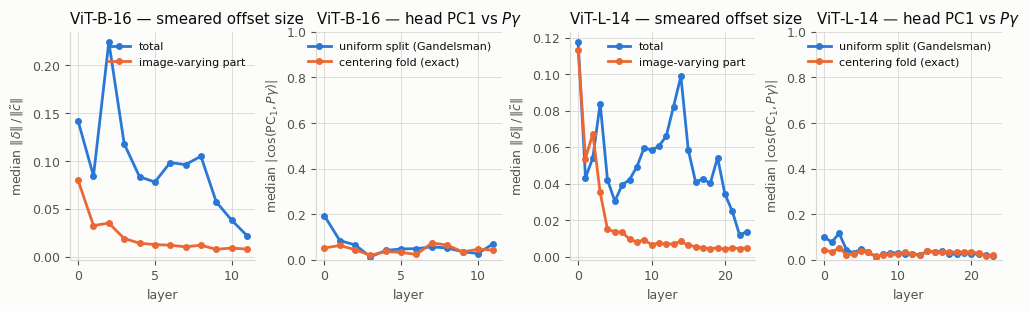

In [6]:
fig, axes = plt.subplots(1, len(RUNS) * 2, figsize=(5.0 * len(RUNS), 3.0), constrained_layout=True)
for j, name in enumerate(RUNS):
    D = DIAG[name]
    L, H = D["rel"].shape
    x = np.arange(L)

    ax = axes[2 * j]
    ax.plot(x, D["rel"].median(1).values.cpu(), color=CLR["orig"], marker="o", ms=4,
            label="total")
    ax.plot(x, D["rel_var"].median(1).values.cpu(), color=CLR["fold"], marker="o", ms=4,
            label="image-varying part")
    ax.set_title(f"{name} — smeared offset size", loc="left", color=INK)
    ax.set_xlabel("layer"); ax.set_ylabel(r"median $\|\delta\|\,/\,\|\tilde c\|$")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[2 * j + 1]
    for tag in ("orig", "fold"):
        ax.plot(x, D["pc1"][tag].median(1).values.cpu(), color=CLR[tag], marker="o", ms=4,
                label=LBL[tag])
    ax.set_ylim(0, 1)
    ax.set_title(f"{name} — head PC1 vs $P\\gamma$", loc="left", color=INK)
    ax.set_xlabel("layer"); ax.set_ylabel(r"median $|\cos(\mathrm{PC}_1, P\gamma)|$")
    ax.legend(frameon=False, fontsize=8)
plt.show()

## Stage 5 — mean-ablation machinery

Mean-ablating a set $S$ means replacing each $c_k(I)$, $k\in S$, by its dataset mean $\bar c_k$:

$$M_S(I) \;=\; \sum_{k\notin S} c_k(I) + \sum_{k\in S}\bar c_k \;=\; M(I) - \sum_{k\in S}\big(c_k(I)-\bar c_k\big)$$

so all curves are cumulative subtractions of mean-centered residuals — one pass, no re-summation.

**The ablated set $S$ is identical across the two conventions** (same physical heads / MLPs / layers,
same order). Only the *value* attributed to each element differs. That is the whole comparison.

Component indexing (matching `prs_hook.py`): `mlp[0]` is the `ln_pre` patch-embedding write, not a
layer, so `mlp[l+1]` is layer `l`'s MLP. `ln_pre` and the fold's `P beta` bias are never ablated.

Zero-shot uses the saved `{dataset}_classifier_{model}.npy` (OpenAI template ensemble); no
renormalization is applied, which is `argmax`-irrelevant and matches `compute_text_explanations.py`.

In [7]:
def ablation_state(run, scheme, mode="mean"):
    """Pack a run into (full embedding, attn residuals, mlp residuals).

    The residual is what gets subtracted when a component is ablated:
      mode="mean" -> c_k - mean_I c_k : the component is REPLACED by its dataset mean.
      mode="zero" -> c_k              : the component is REMOVED outright.
    Both are exact because the decomposition is linear in the components; they differ only in the
    reference the ablation moves to.
    """
    d = run[scheme]
    full = d["attn"].sum((1, 2)) + d["mlp"].sum(1) + d["bias"]
    if mode == "zero":
        return full, d["attn"], d["mlp"]
    return full, d["attn"] - d["attn"].mean(0, keepdim=True), d["mlp"] - d["mlp"].mean(0, keepdim=True)


def top1(emb, classifier, labels):
    return accuracy(emb @ classifier, labels, topk=(1,))[0] * 100   # `accuracy` already divides by N


def ablation_curve(run, scheme, groups, classifier, mode="mean"):
    """groups: list of (attn_idx, mlp_idx); attn_idx = list of (l,h), mlp_idx = list of m.

    Returns cumulative (n_ablated, top1, cosine-to-true) after ablating groups[:i] for i=0..len."""
    full, ra, rm = ablation_state(run, scheme, mode)
    labels, emb = run["labels"], run["emb"]
    cur = full.clone()
    n, accs, coss, ns = 0, [top1(cur, classifier, labels)], [
        torch.nn.functional.cosine_similarity(cur, emb, dim=-1).mean().item()], [0]
    for a_idx, m_idx in groups:
        for (l, h) in a_idx:
            cur -= ra[:, l, h, :]
        for m in m_idx:
            cur -= rm[:, m, :]
        n += len(a_idx) + len(m_idx)
        ns.append(n)
        accs.append(top1(cur, classifier, labels))
        coss.append(torch.nn.functional.cosine_similarity(cur, emb, dim=-1).mean().item())
    del full, ra, rm, cur; torch.cuda.empty_cache()
    return np.array(ns), np.array(accs), np.array(coss)


CLS = {n: torch.tensor(np.load(f"{OUT_DIR}/{DATASET}_classifier_{n}.npy")).float().to(DEVICE)
       for n in RUNS}
for n in RUNS:
    print(f"{n}: full-model zero-shot top-1 = {top1(RUNS[n]['emb'], CLS[n], RUNS[n]['labels']):.2f}%"
          f"   (decomposed sum: {top1(total(RUNS[n], 'fold'), CLS[n], RUNS[n]['labels']):.2f}%)")

ViT-B-16: full-model zero-shot top-1 = 69.50%   (decomposed sum: 69.50%)
ViT-L-14: full-model zero-shot top-1 = 74.60%   (decomposed sum: 74.60%)


In [8]:
def layer_groups(L, H, order):
    """One group per transformer layer = its H attention heads + its MLP."""
    ls = range(L) if order == "early" else range(L - 1, -1, -1)
    return [([(l, h) for h in range(H)], [l + 1]) for l in ls]


def mlp_groups(L, order):
    """One group per MLP (mlp[0] = ln_pre is excluded)."""
    ms = range(1, L + 1) if order == "early" else range(L, 0, -1)
    return [([], [m]) for m in ms]


def head_groups(L, H, order):
    """One group per attention head, swept layer-by-layer."""
    ls = range(L) if order == "early" else range(L - 1, -1, -1)
    return [([(l, h)], []) for l in ls for h in range(H)]


def run_experiment(builder, tag, xlabel):
    """Run `builder(L, H, order)` for both orders, both schemes, both models."""
    out = {}
    for name in RUNS:
        L, H = RUNS[name]["orig"]["attn"].shape[1:3]
        for order in ("early", "late"):
            groups = builder(L, H, order)
            for scheme in ("orig", "fold"):
                for mode in ("mean", "zero"):
                    out[(name, order, scheme, mode)] = ablation_curve(
                        RUNS[name], scheme, groups, CLS[name], mode=mode)
    plot_experiment(out, tag, xlabel)
    return out


MODE_LS = {"mean": "-", "zero": (0, (4, 2))}          # colour = LN convention, dash = ablation mode


def plot_experiment(out, tag, xlabel):
    names = list(RUNS)
    fig, axes = plt.subplots(1, 2 * len(names), figsize=(4.6 * len(names), 3.1),
                             constrained_layout=True, squeeze=False)
    axes = axes[0]
    for j, name in enumerate(names):
        base = top1(RUNS[name]["emb"], CLS[name], RUNS[name]["labels"])
        for i, order in enumerate(("early", "late")):
            ax = axes[2 * j + i]
            ax.axhline(base, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
            for scheme in ("orig", "fold"):
                for mode in ("mean", "zero"):
                    ns, ac, _ = out[(name, order, scheme, mode)]
                    ax.plot(ns, ac, color=CLR[scheme], ls=MODE_LS[mode], zorder=3,
                            label=f"{LBL[scheme]}, {mode}-abl", solid_capstyle="round")
            ax.set_title(f"{name} — {tag}, {order}-first", loc="left", color=INK)
            ax.set_xlabel(xlabel)
            if i == 0:
                ax.set_ylabel("zero-shot top-1 (%)")
            ax.legend(frameon=False, fontsize=7, loc="best")
    plt.show()


def summarize(out, tag, mode="mean"):
    rows = []
    for name in RUNS:
        for order in ("early", "late"):
            ns, ao, _ = out[(name, order, "orig", mode)]
            _, af, _ = out[(name, order, "fold", mode)]
            rows.append([name, tag, order, mode,
                         f"{ao[len(ao)//2]:.2f}", f"{af[len(af)//2]:.2f}",
                         f"{af[len(af)//2]-ao[len(ao)//2]:+.2f}",
                         f"{ao[-1]:.2f}", f"{af[-1]:.2f}", f"{af[-1]-ao[-1]:+.2f}",
                         f"{np.trapz(af, ns)/np.trapz(ao, ns):.4f}"])
    return rows

## Stage 6 — experiment A: ablate whole layers (attention heads + MLP), two orders, mean and zero

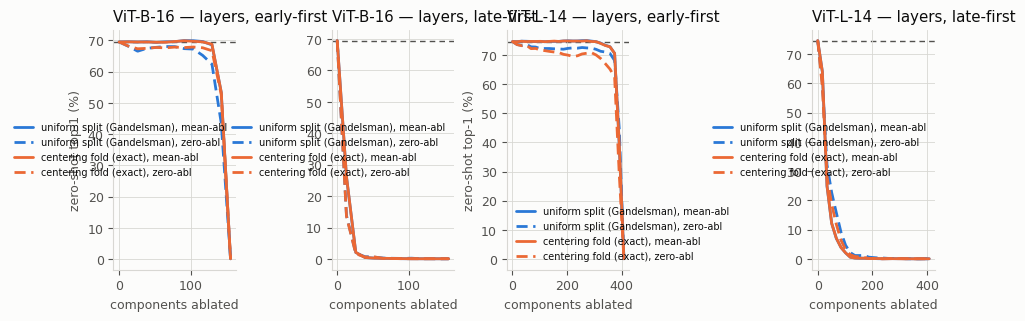

In [9]:
EXP_LAYER = run_experiment(layer_groups, "layers", "components ablated")

## Stage 7 — experiment B: ablate MLPs only, two orders, mean and zero

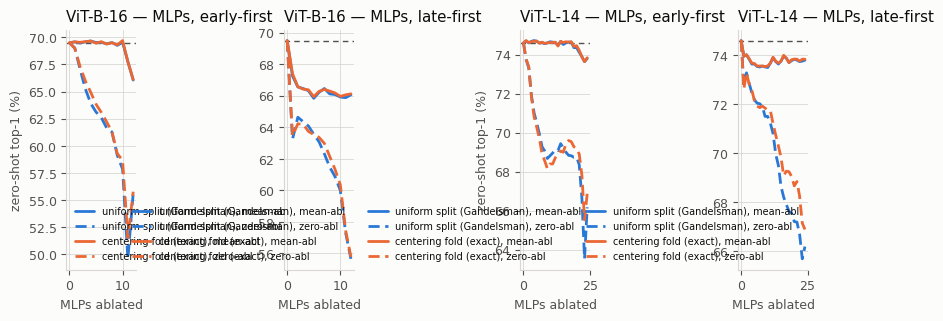

In [10]:
EXP_MLP = run_experiment(lambda L, H, o: mlp_groups(L, o), "MLPs", "MLPs ablated")

## Stage 8 — experiment C: ablate attention heads only, two orders, mean and zero

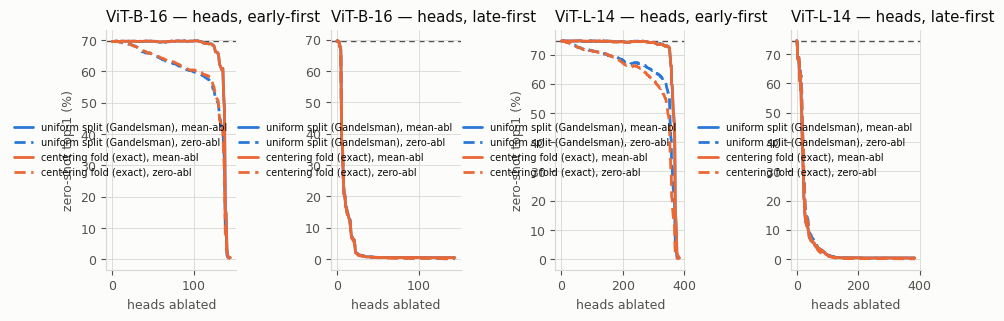

In [11]:
EXP_HEAD = run_experiment(head_groups, "heads", "heads ablated")

## Stage 9 — summary

`mid` = accuracy at the halfway point of the sweep, `end` = fully ablated, `AUC ratio` = area under
the fold curve / area under the uniform-split curve (>1 means the fold keeps more accuracy over the
whole sweep).

Solid lines are mean ablation (component -> its dataset mean), dashed are zero ablation
(component -> 0); colour is the LayerNorm convention. The `ablation` column says which.

One asymmetry to keep in mind when reading the `end` column: with **everything** mean-ablated the
uniform split leaves a constant vector (chance-level by construction), whereas the fold still carries
`P beta / ||M(I)||` — a fixed direction with a per-image positive scale. Under **zero** ablation both
conventions collapse to the same leftover `bias` term, so the endpoint is not informative there
either. In both cases the informative region is the middle of each sweep.

In [12]:
rows = []
for mode in ("mean", "zero"):
    rows += (summarize(EXP_LAYER, "layers", mode) + summarize(EXP_MLP, "MLPs", mode)
             + summarize(EXP_HEAD, "heads", mode))
print(tabulate(rows, headers=["model", "family", "order", "ablation", "mid orig", "mid fold",
                              "d mid", "end orig", "end fold", "d end", "AUC ratio"]))

# mean vs zero, holding the LN convention fixed: how much of the damage is the reference choice?
cmp_rows = []
for tag, out in (("layers", EXP_LAYER), ("MLPs", EXP_MLP), ("heads", EXP_HEAD)):
    for name in RUNS:
        for order in ("early", "late"):
            for scheme in ("orig", "fold"):
                _, am, _ = out[(name, order, scheme, "mean")]
                _, az, _ = out[(name, order, scheme, "zero")]
                h = len(am) // 2
                cmp_rows.append([name, tag, order, LBL[scheme], f"{am[h]:.2f}", f"{az[h]:.2f}",
                                 f"{az[h]-am[h]:+.2f}", f"{am[-1]:.2f}", f"{az[-1]:.2f}"])
print()
print(tabulate(cmp_rows, headers=["model", "family", "order", "LN convention", "mid mean-abl",
                                  "mid zero-abl", "d (zero - mean)", "end mean-abl", "end zero-abl"]))

# noise floor: a difference smaller than this is not evidence of anything
for name in RUNS:
    N = RUNS[name]["emb"].shape[0]
    p = top1(RUNS[name]["emb"], CLS[name], RUNS[name]["labels"]) / 100
    se = (p * (1 - p) / N) ** 0.5 * 100
    print(f"{name}: N={N}, binomial SE of top-1 = {se:.2f} pts "
          f"(paired curves share the same images, so the paired SE is smaller, but ~{se:.1f} "
          f"bounds what a single cell can mean)")

model     family    order    ablation      mid orig    mid fold    d mid    end orig    end fold    d end    AUC ratio
--------  --------  -------  ----------  ----------  ----------  -------  ----------  ----------  -------  -----------
ViT-B-16  layers    early    mean             69.58       69.64     0.06        0.1         0.1      0          0.9997
ViT-B-16  layers    late     mean              0.18        0.18     0           0.1         0.1      0          1.0012
ViT-L-14  layers    early    mean             74.86       74.8     -0.06        0.1         0.1      0          0.9996
ViT-L-14  layers    late     mean              0.18        0.18     0           0.1         0.1      0          1.0006
ViT-B-16  MLPs      early    mean             69.54       69.6      0.06       66.06       66.12     0.06       1.0003
ViT-B-16  MLPs      late     mean             66.22       66.28     0.06       66.06       66.12     0.06       1.001
ViT-L-14  MLPs      early    mean             74.

---
# Part 2 — ResNet: block-neuron-head-token, and what we already have

The write-up's decomposition:

$$M_{\rm image}(I)=\sum_{k=0}^{L}\sum_{n=1}^{C}\sum_{h=1}^{H}\sum_{i=0}^{K}\boldsymbol r^{n,h,k}_i,
\qquad \boldsymbol r^{n,h,k}_i = a^h_i(I)\;c_k(i,n)\;W^{n,h}_{VO}$$

with $c_k(i,n)=[G_kF_k(\boldsymbol x_{k-1})]_{i,n}$ and $G_L=D_L$, $G_k=G_{k+1}S_{k+1}D_k$.

**Mapping onto the repo (`utils/models/resnet_prs.py`):**

| write-up | code |
|---|---|
| $D_\ell$ (frozen post-add ReLU) | `gate = (pre > 0)` in `_bottleneck_capture` |
| $S_\ell$ (stride shortcut) | `_downsample_linear_only` (avgpool → 1x1 conv → BN scale) |
| $G_k = G_{k+1}S_{k+1}D_k$ | the `contribs = [gate * _downsample_linear_only(ds, c) for c in contribs]` loop |
| $F_0:=\Sigma$, $\boldsymbol x_{-1}:=I$ | `contribs = [visual.stem(image)]` |
| $a^h_i(I)$ | `attnpool_frozen_weights` |
| $\sum_n\sum_i \boldsymbol r^{n,h,k}_i$ | `c_lh` from `attnpool_split` — **already computed and already saved** |

So $c_k(i,n)$ and $a^h_i$ both exist; what the repo never forms is the **product before contraction**.
`head_value` does `einsum("bhi,ibhd->bhd", attn, v)` — that single line sums out $i$, and $W_v$ has
already mixed all $C$ channels, summing out $n$. Below we form the four-index object explicitly.

**One deviation from the equations worth flagging.** $S_\ell$ is written as a linear map, but the
shortcut's BatchNorm is *affine*: $S_\ell(x)=\mathrm{lin}(x)+\text{shift}$. `_bottleneck_capture`
attributes that constant `shift` to block $\ell$'s own write
(`new_write = gate * (branch + shift)`) rather than propagating it. That keeps the sum exact but
means block $\ell$'s contribution silently absorbs a downstream-shortcut constant — the same species
of choice as the LayerNorm split interrogated in Part 1, though here the term is input-independent.

In [13]:
import utils.models.resnet_prs as rprs

RN_NAME, RN_PRE = "RN50", "openai"
rn, _, rn_pre = create_model_and_transforms(RN_NAME, pretrained=RN_PRE, precision="fp32")
rn.to(DEVICE).eval()
visual = rn.visual

ds_rn = ImageNet(root=DATA_PATH + "imagenet/", split="val", transform=rn_pre)
imgs = torch.stack([ds_rn[i][0] for i in (0, 1234)]).to(DEVICE)
print("image batch:", tuple(imgs.shape), " heads:", visual.attnpool.num_heads)

image batch: (2, 3, 224, 224)  heads: 32


In [14]:
@torch.no_grad()
def decompose_resnet_fine(visual, image):
    """The four-index ingredients: a^h_i, c_k(i,n), W^{n,h}_VO, plus the positional/bias term.

    Returns
        a     [B, H, K+1]        frozen class-token pooling weights  a^h_i(I)
        c     [L+1, K+1, B, C]   c_k(i,n) = [G_k F_k(x_{k-1})]_{i,n}
        W_VO  [H, C, out_dim]    W^{n,h}_VO = column n of  W_o^h W_v^h
        c_pos [B, out_dim]       positional + value-bias + out-proj-bias (content-free)
    """
    ap = visual.attnpool
    H, C = ap.num_heads, ap.v_proj.in_features
    dh, out_dim = C // H, ap.c_proj.out_features

    with rprs._full_fp32():
        contribs, Z = rprs.decompose_feature_map(visual, image, check=True)   # G_k F_k(x_{k-1})
        a = rprs.attnpool_frozen_weights(ap, Z)                               # [B, H, K+1]
        c = torch.stack([rprs._tokens_from_map(g) for g in contribs], 0)      # [L+1, K+1, B, C]

        Wv = ap.v_proj.weight.reshape(H, dh, C)                # [H, dh, C]
        Wo = ap.c_proj.weight.reshape(out_dim, H, dh)          # [out, H, dh]
        W_VO = torch.einsum("ohd,hdn->hno", Wo, Wv)            # [H, C, out]

        # content-free part: positional embedding through v_proj (with b_v), pooled, then W_o, + b_o
        P = ap.positional_embedding.to(Z.dtype)                                    # [K+1, C]
        v_pos = torch.nn.functional.linear(P, ap.v_proj.weight, ap.v_proj.bias)
        v_pos = v_pos.reshape(P.shape[0], H, dh)
        c_pos = torch.einsum("bhi,ihd,ohd->bo", a, v_pos, Wo) + ap.c_proj.bias[None, :]
    return a, c, W_VO, c_pos


a, c, W_VO, c_pos = decompose_resnet_fine(visual, imgs)
B = imgs.shape[0]
Lp1, K1, _, C = c.shape
H, _, OUT = W_VO.shape
print(f"a     {tuple(a.shape)}\nc     {tuple(c.shape)}\nW_VO  {tuple(W_VO.shape)}\nc_pos {tuple(c_pos.shape)}")
print(f"\nblocks L+1={Lp1}  tokens K+1={K1}  neurons C={C}  heads H={H}  out_dim={OUT}")

a     (2, 32, 50)
c     (17, 50, 2, 2048)
W_VO  (32, 2048, 1024)
c_pos (2, 1024)

blocks L+1=17  tokens K+1=50  neurons C=2048  heads H=32  out_dim=1024


### Check 1 — the full four-index sum returns the embedding

We form the scalar field $s^{n,h,k}_i = a^h_i\,c_k(i,n)$ explicitly (all four indices materialized)
and only then contract it against $W^{n,h}_{VO}$. Nothing is collapsed early, so this really does
test $\sum_{k,n,h,i}\boldsymbol r^{n,h,k}_i + \boldsymbol c_{\rm pos} = \mathrm{visual}(I)$.

In [15]:
with rprs._full_fp32():
    real = visual(imgs)                                              # ground truth

    # the four-index scalar field  s^{n,h,k}_i = a^h_i * c_k(i,n)    [B, L+1, C, H, K+1]
    s = torch.einsum("bhi,kibn->bknhi", a, c)

    # Contract against W^{n,h}_VO one (k, h) at a time: neither the block nor the head index is
    # ever collapsed by the contraction itself, so this really is the four-index sum.
    c_kh_fine = torch.zeros(B, Lp1, H, OUT, device=s.device, dtype=s.dtype)
    mag = torch.zeros(B, Lp1, H, K1, device=s.device, dtype=s.dtype)   # ||r^{h,k}_i||, for later
    for k in range(Lp1):
        for h in range(H):
            r_ni = s[:, k, :, h, :]                        # [B, C, K+1]   r-coefficients of (k,h)
            r_i = r_ni.transpose(1, 2) @ W_VO[h]           # [B, K+1, out] sum over neurons n
            mag[:, k, h] = r_i.norm(dim=-1)
            c_kh_fine[:, k, h] = r_i.sum(1)                # sum over tokens i

    recon_fine = c_kh_fine.sum((1, 2)) + c_pos             # sum over blocks k and heads h
    err = (recon_fine - real).abs().max().item()
    cos = torch.nn.functional.cosine_similarity(recon_fine, real, dim=-1).min().item()

print(f"s (four-index scalar field): {tuple(s.shape)}  = {s.numel():,} scalars "
      f"({s.numel()*4/2**30:.2f} GiB at fp32)")
print(f"materializing r itself would need {s.numel()*OUT*4/2**40:.1f} TiB -- hence the contraction")
print(f"\nmax |sum_(k,n,h,i) r + c_pos  -  visual(I)| = {err:.3e}   min cos = {cos:.8f}")
assert err < 1e-2 * real.abs().max().item(), "four-index decomposition does not reproduce visual(I)"
print("PASS - the full block-neuron-head-token sum returns the original output embedding.")

s (four-index scalar field): (2, 17, 2048, 32, 50)  = 111,411,200 scalars (0.42 GiB at fp32)
materializing r itself would need 0.4 TiB -- hence the contraction

max |sum_(k,n,h,i) r + c_pos  -  visual(I)| = 1.103e-06   min cos = 1.00000000
PASS - the full block-neuron-head-token sum returns the original output embedding.


### Check 2 — collapsing $n$ and $i$ lands exactly on the repo's `c_lh`

$\boldsymbol r^{h,k}=\sum_n\sum_i \boldsymbol r^{n,h,k}_i = a^h_i[G_kF_k(\boldsymbol x_{k-1})]_i W^h_{VO}$ must equal
`attnpool_split(...)["c_lh"]` — i.e. the coarse granularity **is** the one already implemented and
already saved to `output_dir` as `{dataset}_attn_RN50_seed_69.npy` (`[N, L+1, H, out_dim]`).

In [16]:
with rprs._full_fp32():
    ref = rprs.decompose_resnet_image(visual, imgs, check=True, vision_proj=True)

d_lh = (c_kh_fine - ref["c_lh"]).abs().max().item()
d_pos = (c_pos - ref["c_pos"]).abs().max().item()
print(f"our (k,h) collapse  {tuple(c_kh_fine.shape)}  vs resnet_prs c_lh  {tuple(ref['c_lh'].shape)}")
print(f"  max |diff| c_lh  = {d_lh:.3e}")
print(f"  max |diff| c_pos = {d_pos:.3e}")
assert d_lh < 1e-2 and d_pos < 1e-2
print("PASS - the coarse granularity is exactly what resnet_prs.py already computes.")

saved = np.load(f"{OUT_DIR}/{DATASET}_attn_{RN_NAME}_seed_{SEED}.npy", mmap_mode="r")
print(f"\nsaved activations {DATASET}_attn_{RN_NAME}_seed_{SEED}.npy : {saved.shape} "
      f"= [N, L+1={Lp1}, H={H}, out_dim={OUT}]  -> already the block-head view")

our (k,h) collapse  (2, 17, 32, 1024)  vs resnet_prs c_lh  (2, 17, 32, 1024)
  max |diff| c_lh  = 7.451e-08
  max |diff| c_pos = 0.000e+00
PASS - the coarse granularity is exactly what resnet_prs.py already computes.

saved activations imagenet_attn_RN50_seed_69.npy : (5000, 17, 32, 1024) = [N, L+1=17, H=32, out_dim=1024]  -> already the block-head view


### The two granularities side by side

`c_pos` is the content-free positional/bias term; it is what `compute_activation_values_resnet.py`
stores in the `mlp` slot so the ViT tooling can be reused.

In [17]:
rows = [
    ["full  (k, n, h, i)", "block x neuron x head x token", f"{Lp1} x {C} x {H} x {K1}",
     f"{Lp1*C*H*K1:,}", f"{Lp1*C*H*K1*OUT*4/2**40:.1f} TiB", "NOT in repo (built here)"],
    ["      (k, h, i)",    "block x head x token",           f"{Lp1} x {H} x {K1}",
     f"{Lp1*H*K1:,}",      f"{Lp1*H*K1*OUT*4/2**20:.0f} MiB", "NOT in repo (built here)"],
    ["coarse (k, h)",      "block x head",                   f"{Lp1} x {H}",
     f"{Lp1*H:,}",         f"{Lp1*H*OUT*4/2**10:.0f} KiB",   "resnet_prs.c_lh - ALREADY HAVE"],
]
print(tabulate(rows, headers=["granularity", "meaning", "shape", "terms/image",
                              "storage/image", "status"]))

granularity         meaning                        shape                  terms/image  storage/image    status
------------------  -----------------------------  -------------------  -------------  ---------------  ------------------------------
full  (k, n, h, i)  block x neuron x head x token  17 x 2048 x 32 x 50     55,705,600  0.2 TiB          NOT in repo (built here)
(k, h, i)           block x head x token           17 x 32 x 50                27,200  106 MiB          NOT in repo (built here)
coarse (k, h)       block x head                   17 x 32                        544  2176 KiB         resnet_prs.c_lh - ALREADY HAVE


### The intermediate $(k,h,i)$ view — which block supplied a head's signal, and where

Summing only over neurons gives $\boldsymbol r^{h,k}_i$: for a chosen head, a spatial map per residual block.
This is the view the write-up motivates ("which spatial locations a head reads from and which block
supplied the signal there"), and it is the piece the current code cannot produce. Its magnitudes were
accumulated as `mag` in the contraction loop above. Token $i=0$ is the prepended mean token, so the
$7\times7$ grid is $i=1..K$.

||r^{h,k}_i|| : (2, 17, 32, 50)   [B, L+1, H, K+1]


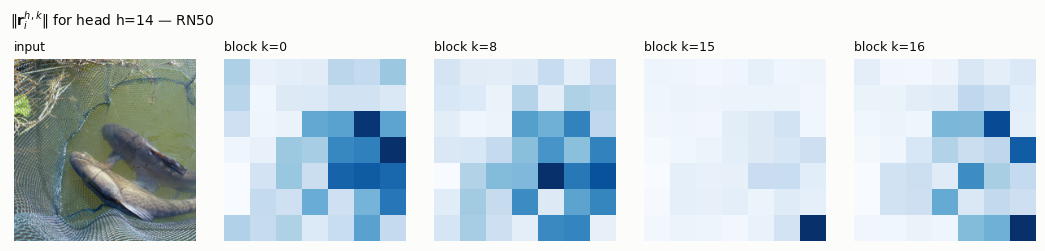


share of head 14's output magnitude by block (top 5):
  block 14:  14.5%
  block  8:  13.3%
  block  4:  12.1%
  block  0:   7.8%
  block  1:   7.7%


In [18]:
print("||r^{h,k}_i|| :", tuple(mag.shape), "  [B, L+1, H, K+1]")

b, head = 0, int(mag[0, :, :, 1:].sum((0, 2)).argmax())        # busiest head on image 0
side = int(round((K1 - 1) ** 0.5))
blocks = [0, Lp1 // 2, Lp1 - 2, Lp1 - 1]

fig, axes = plt.subplots(1, len(blocks) + 1, figsize=(2.1 * (len(blocks) + 1), 2.4),
                         constrained_layout=True)
im = imgs[b].cpu().permute(1, 2, 0).numpy()
axes[0].imshow((im - im.min()) / (im.ptp() + 1e-9)); axes[0].axis("off")
axes[0].set_title("input", loc="left", fontsize=9, color=INK)
for ax, k in zip(axes[1:], blocks):
    ax.imshow(mag[b, k, head, 1:].reshape(side, side).cpu(), cmap="Blues")
    ax.axis("off")
    ax.set_title(f"block k={k}", loc="left", fontsize=9, color=INK)
fig.suptitle(rf"$\|\mathbf{{r}}^{{h,k}}_i\|$ for head h={head} — {RN_NAME}", x=0.01, ha="left",
             fontsize=10, color=INK)
plt.show()

print(f"\nshare of head {head}'s output magnitude by block (top 5):")
sh = mag[b, :, head].sum(-1); sh = sh / sh.sum()
for k in sh.topk(5).indices.tolist():
    print(f"  block {k:2d}: {sh[k]*100:5.1f}%")

### Zero-shot under block-wise mean ablation (ascending / descending topological order)

Same intervention as Part 1, on the coarse $(k,h)$ granularity: ablating block $k$ replaces all $H=32$
of its head contributions $\boldsymbol r^{h,k}$ by their dataset means. `c_pos` (content-free
positional/bias) is never ablated, the analogue of `ln_pre` on the ViT side.

The saved `{dataset}_attn_RN50_...` / `_mlp_RN50_...` already have exactly the layout
`ablation_curve` expects (`[N, L+1, H, d]` + `[N, 1, d]`, summing to the L2-normalized embedding), so
this reuses the Part 1 machinery verbatim — no ResNet-specific ablation code.

Both orders are topological: **ascending** ablates the stem first and walks forward to block 16,
**descending** starts at the last block and walks back. They meet at the same fully-ablated endpoint.

In [19]:
def load_npy_to_gpu(path, device=DEVICE, chunk=128):
    """Stream a large .npy straight onto the GPU; never materialize it in host RAM (12 GB cgroup)."""
    a = np.load(path, mmap_mode="r")
    out = torch.empty(tuple(a.shape), dtype=torch.float32, device=device)
    for i in range(0, a.shape[0], chunk):
        out[i:i + chunk] = torch.from_numpy(np.ascontiguousarray(a[i:i + chunk])).to(device, torch.float32)
    return out


RN = {"exact": {
    "attn": load_npy_to_gpu(f"{OUT_DIR}/{DATASET}_attn_{RN_NAME}_seed_{SEED}.npy"),   # [N, L+1, H, d]
    "mlp":  load_npy_to_gpu(f"{OUT_DIR}/{DATASET}_mlp_{RN_NAME}_seed_{SEED}.npy"),    # [N, 1, d] = c_pos
}}
RN["exact"]["bias"] = torch.zeros_like(RN["exact"]["mlp"][:, 0])
RN["emb"] = load_npy_to_gpu(f"{OUT_DIR}/{DATASET}_embeddings_{RN_NAME}_seed_{SEED}.npy")
RN["labels"] = torch.tensor(np.load(f"{OUT_DIR}/{DATASET}_labels_{RN_NAME}_seed_{SEED}.npy")).to(DEVICE)
CLS_RN = torch.tensor(np.load(f"{OUT_DIR}/{DATASET}_classifier_{RN_NAME}.npy")).float().to(DEVICE)

# same verification gate as Part 1: the components must reproduce the saved embedding
s_rn = _stats(total(RN, "exact"), RN["emb"])
print(f"attn {tuple(RN['exact']['attn'].shape)}  c_pos {tuple(RN['exact']['mlp'].shape)}  "
      f"emb {tuple(RN['emb'].shape)}")
print(f"sum(components) vs saved embedding: max_abs={s_rn['max_abs']:.2e}  min_cos={s_rn['min_cos']:.8f}")
assert s_rn["max_abs"] < 1e-4, s_rn
RN_BASE = top1(RN["emb"], CLS_RN, RN["labels"])
print(f"{RN_NAME} full-model zero-shot top-1 = {RN_BASE:.2f}%   "
      f"(decomposed sum: {top1(total(RN, 'exact'), CLS_RN, RN['labels']):.2f}%)")

/tmp/ipykernel_1251334/767076801.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  out[i:i + chunk] = torch.from_numpy(np.ascontiguousarray(a[i:i + chunk])).to(device, torch.float32)


attn (5000, 17, 32, 1024)  c_pos (5000, 1, 1024)  emb (5000, 1024)
sum(components) vs saved embedding: max_abs=2.68e-07  min_cos=0.99999982
RN50 full-model zero-shot top-1 = 58.88%   (decomposed sum: 58.88%)


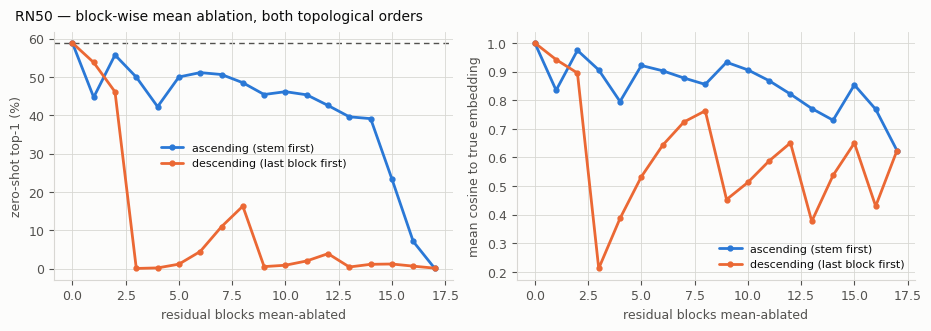

RN50 baseline = 58.88%   (N=5000, binomial SE = 0.70 pts)
order         # blocks ablated    last block ablated    top-1 (%)    delta vs full    cos to true
----------  ------------------  --------------------  -----------  ---------------  -------------
ascending                    1                     0        44.7            -14.18         0.8346
ascending                    4                     3        42.24           -16.64         0.7954
ascending                    8                     7        48.5            -10.38         0.8552
ascending                   12                    11        42.56           -16.32         0.8212
ascending                   17                    16         0.1            -58.78         0.6242
descending                   1                    16        53.78            -5.1          0.9418
descending                   4                    13         0.16           -58.72         0.3873
descending                   8                     9        

In [20]:
def block_groups(n_blocks, n_heads, order):
    """One group per residual block = all H of its head contributions."""
    ks = range(n_blocks) if order == "ascending" else range(n_blocks - 1, -1, -1)
    return [([(k, h) for h in range(n_heads)], []) for k in ks]


N_BLK, N_HEAD = RN["exact"]["attn"].shape[1], RN["exact"]["attn"].shape[2]
RN_ABL = {o: ablation_curve(RN, "exact", block_groups(N_BLK, N_HEAD, o), CLS_RN)
          for o in ("ascending", "descending")}

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.2), constrained_layout=True)
ORD_CLR = {"ascending": "#2a78d6", "descending": "#eb6834"}
for ax, (val, ylab) in zip(axes, [(1, "zero-shot top-1 (%)"), (2, "mean cosine to true embedding")]):
    if val == 1:
        ax.axhline(RN_BASE, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
    for o in ("ascending", "descending"):
        ns, acc, cos = RN_ABL[o]
        y = acc if val == 1 else cos
        ax.plot(ns // N_HEAD, y, color=ORD_CLR[o], marker="o", ms=3.5, zorder=3,
                label=f"{o} (stem first)" if o == "ascending" else f"{o} (last block first)",
                solid_capstyle="round")
    ax.set_xlabel("residual blocks mean-ablated"); ax.set_ylabel(ylab)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"{RN_NAME} — block-wise mean ablation, both topological orders", x=0.01, ha="left",
             fontsize=10, color=INK)
plt.show()

rows = []
for o in ("ascending", "descending"):
    ns, acc, cos = RN_ABL[o]
    order_ks = list(range(N_BLK)) if o == "ascending" else list(range(N_BLK - 1, -1, -1))
    for i in (1, 4, 8, 12, N_BLK):
        rows.append([o, i, order_ks[i - 1], f"{acc[i]:.2f}", f"{acc[i] - RN_BASE:+.2f}", f"{cos[i]:.4f}"])
print(f"{RN_NAME} baseline = {RN_BASE:.2f}%   (N={RN['emb'].shape[0]}, "
      f"binomial SE = {((RN_BASE/100)*(1-RN_BASE/100)/RN['emb'].shape[0])**0.5*100:.2f} pts)")
print(tabulate(rows, headers=["order", "# blocks ablated", "last block ablated",
                              "top-1 (%)", "delta vs full", "cos to true"]))

### Component geometry: how big is each block, and which way does it point?

Two quantities per component, both measured against the model's own final embedding $M(I)$
(components are already divided by $\|M(I)\|$, so $\|M\|=1$ and the norm ratio is just $\|c\|$):

- **relative L2 norm** $\|c\|/\|M\|$ — how much a component writes.
- **cosine to $M$** — whether it writes *along* the final embedding (constructive), orthogonally
  (a direction the classifier may still use), or against it.

Norm and cosine answer different questions and a large norm at a near-zero cosine is the interesting
case, so they get their own panel each rather than being mixed on one axis. The line is the whole
block (all 32 heads summed); the band is the spread across its individual heads; the dashed rule is
the content-free `c_pos` term.

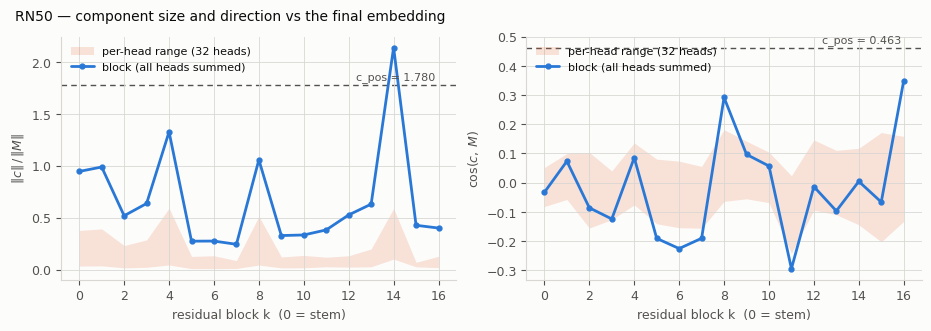

c_pos: rel norm 1.780, cos +0.463
sum of block rel norms = 11.44  (>> 1: components largely cancel)

largest blocks by relative L2 norm:
  block k    rel norm    cos to M  per-head rel norm    per-head cos
---------  ----------  ----------  -------------------  --------------
       14      2.1392      0.0044  0.1013-0.5895        -0.144..+0.118
        4      1.3272      0.0855  0.0446-0.5921        -0.076..+0.136
        8      1.0576      0.2917  0.0438-0.5131        -0.064..+0.181
        1      0.9884      0.0734  0.0362-0.3921        -0.058..+0.100
        0      0.9458     -0.033   0.0343-0.3771        -0.082..+0.052


In [21]:
A_rn, M_rn = RN["exact"]["attn"], RN["emb"]                     # [N, K, H, d], [N, d]
mnorm = M_rn.norm(dim=-1)                                        # [N]
c_blk = A_rn.sum(2)                                              # [N, K, d]  block totals

# cheap cosines via einsum (avoids broadcasting an [N, K, H, d] product)
dot_h = torch.einsum("nkhd,nd->nkh", A_rn, M_rn)
dot_b = torch.einsum("nkd,nd->nk", c_blk, M_rn)
norm_h, norm_b = A_rn.norm(dim=-1), c_blk.norm(dim=-1)

rel_h = (norm_h / mnorm[:, None, None]).mean(0)                  # [K, H]
rel_b = (norm_b / mnorm[:, None]).mean(0)                        # [K]
cos_h = (dot_h / (norm_h * mnorm[:, None, None])).mean(0)        # [K, H]
cos_b = (dot_b / (norm_b * mnorm[:, None])).mean(0)              # [K]

c_pos_rn = RN["exact"]["mlp"][:, 0]
rel_pos = (c_pos_rn.norm(dim=-1) / mnorm).mean().item()
cos_pos = (torch.einsum("nd,nd->n", c_pos_rn, M_rn) / (c_pos_rn.norm(dim=-1) * mnorm)).mean().item()

x = np.arange(N_BLK)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.2), constrained_layout=True)
for ax, (blk, per_h, ref, lab) in zip(axes, [
        (rel_b, rel_h, rel_pos, r"$\|c\|\,/\,\|M\|$"),
        (cos_b, cos_h, cos_pos, r"$\cos(c,\,M)$")]):
    ax.fill_between(x, per_h.min(1).values.cpu(), per_h.max(1).values.cpu(),
                    color=CLR["fold"], alpha=0.18, lw=0, label="per-head range (32 heads)")
    ax.plot(x, blk.cpu(), color=CLR["orig"], marker="o", ms=3.5, zorder=3,
            label="block (all heads summed)", solid_capstyle="round")
    ax.axhline(ref, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.annotate(f"c_pos = {ref:.3f}", (N_BLK - 1, ref), textcoords="offset points",
                xytext=(-2, 4), ha="right", fontsize=8, color=MUTED)
    ax.set_xlabel("residual block k  (0 = stem)"); ax.set_ylabel(lab)
    ax.legend(frameon=False, fontsize=8, loc="best")
fig.suptitle(f"{RN_NAME} — component size and direction vs the final embedding", x=0.01, ha="left",
             fontsize=10, color=INK)
plt.show()

top = rel_b.topk(5).indices.tolist()
print(f"c_pos: rel norm {rel_pos:.3f}, cos {cos_pos:+.3f}")
print(f"sum of block rel norms = {rel_b.sum():.2f}  (>> 1: components largely cancel)")
print("\nlargest blocks by relative L2 norm:")
print(tabulate([[k, f"{rel_b[k]:.4f}", f"{cos_b[k]:+.4f}",
                 f"{rel_h[k].min():.4f}-{rel_h[k].max():.4f}",
                 f"{cos_h[k].min():+.3f}..{cos_h[k].max():+.3f}"] for k in top],
               headers=["block k", "rel norm", "cos to M", "per-head rel norm", "per-head cos"]))

### Auditing the frozen-ReLU decomposition

Four diagnostics, each aimed at a specific objection to freezing the ReLUs as $D_k(I)$:

1. **Gate survival** — mean of $\prod_{j=l}^{L} D_j$ as a function of $l$. If almost nothing survives,
   early-block attributions are the residue of a near-total annihilation.
   *Caveat handled below:* the literal product is only shape-compatible **within a stage** ($S_\ell$
   mixes channels and halves resolution at stage boundaries), so we report the literal within-stage
   product **and** the shape-safe global version $\|G_l F_l\| / \|G_l^{\text{no-gate}} F_l\|$ — the
   same propagation with every gate forced open.
2. **Mask agreement across images** (Jaccard on gate supports). $D_k$ is per-image, so $G_k$ is
   nominally a different linear map for every input. If the supports largely coincide, that objection
   is weak. Compared against the Jaccard a pair of *independent* masks of the same density would give.
3. **Cancellation ratio** $\sum_k\|c_k\| / \|\sum_k c_k\|$. If large, the summands are dominated by
   mutually cancelling mass and per-component attribution is close to meaningless *however* the ReLU
   is handled.
4. **Frozen-gate direct effect vs. actual ablation (NMAE)** — the ResNet analogue of the ~49% NMAE
   reported for GPT-2 attention heads. For each block: the decomposition's predicted mean-ablation
   delta $c_k(I)-\bar c_k$, versus **re-running the real network** with block $k$'s write replaced by
   its dataset mean and every downstream ReLU recomputed.

subset rows: 5000   audit sample: 1000 images (1 per class)


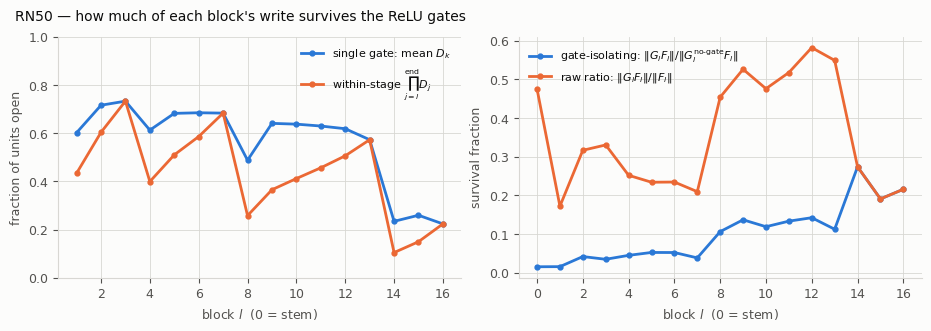

  block l  mean D_l    within-stage prod      gate survival    raw ||G F||/||F||
---------  ----------  -------------------  ---------------  -------------------
        0  -           -                              0.015                0.475
        1  0.602       0.433                          0.015                0.172
        2  0.716       0.603                          0.041                0.316
        3  0.733       0.733                          0.034                0.33
        4  0.612       0.399                          0.044                0.251
        5  0.682       0.510                          0.052                0.234
        6  0.684       0.586                          0.052                0.234
        7  0.683       0.683                          0.038                0.209
        8  0.488       0.258                          0.106                0.454
        9  0.640       0.365                          0.136                0.526
       10  0.637       0.411 

In [22]:
from utils.datasets.dataset_helpers import dataset_subset

# Same subset AND row order the saved activations were computed on, so rows line up with RN[...].
ds_sub = dataset_subset(ds_rn, samples_per_class=SPC, tot_samples_per_class=TOT, seed=SEED)
IDX_ALL = list(range(0, len(ds_sub), SPC))      # 1000 images == exactly one per ImageNet class
print(f"subset rows: {len(ds_sub)}   audit sample: {len(IDX_ALL)} images (1 per class)")

def rn_images(sel):
    return torch.stack([ds_sub[j][0] for j in sel]).to(DEVICE)


@torch.no_grad()
def decompose_with_writes(visual, image):
    """rprs.decompose_feature_map, also returning each block's raw write F_k, its post-add ReLU gate
    D_k, and the SAME propagation with every gate forced open (`nogate`).

    The gate-free copy is what makes "how much does prod_j D_j destroy" well posed: a literal
    prod_{j=l}^{L} D_j is not shape-compatible across stages, but ||G_l F_l|| / ||G_l^no-gate F_l|| is.
    """
    with rprs._full_fp32():
        x = visual.stem(image)
        contribs, nogate, raw, gates = [x], [x], [x], []
        for layer in (visual.layer1, visual.layer2, visual.layer3, visual.layer4):
            for block in layer:
                x_next, branch, gate, shift = rprs._bottleneck_capture(block, x)
                ds = block.downsample
                if ds is not None:
                    contribs = [gate * rprs._downsample_linear_only(ds, t) for t in contribs]
                    nogate = [rprs._downsample_linear_only(ds, t) for t in nogate]
                    write = branch + shift[None, :, None, None]
                else:
                    contribs = [gate * t for t in contribs]
                    write = branch
                contribs.append(gate * write)
                nogate.append(write)
                raw.append(write)
                gates.append(gate)
                x = x_next
    return contribs, nogate, raw, gates, x


G_IMGS = rn_images(IDX_ALL[:64])
contribs_g, nogate_g, raw_g, gates_g, Z_g = decompose_with_writes(visual, G_IMGS)

# (a) per-block gate openness, (b) literal within-stage product, (c) shape-safe global survival
stage_sizes = [len(visual.layer1), len(visual.layer2), len(visual.layer3), len(visual.layer4)]
stage_end, o = {}, 1
for n_blk in stage_sizes:                       # blocks are 1..L; block 0 is the stem
    for b in range(o, o + n_blk):
        stage_end[b] = o + n_blk - 1
    o += n_blk

open_rate = np.array([g.float().mean().item() for g in gates_g])          # [L]
surv_stage = np.full(N_BLK, np.nan)
for l in range(1, N_BLK):
    m = gates_g[l - 1].bool()
    for j in range(l, stage_end[l]):
        m &= gates_g[j].bool()
    surv_stage[l] = m.float().mean().item()
flat = lambda t: t.reshape(t.shape[0], -1).norm(dim=-1)
# gate-isolating survival: identical propagation, gates on vs gates forced open. This is the
# faithful form of ||diag(M_l) f_l|| / ||f_l|| -- it coincides with it exactly wherever S_l = I,
# and unlike the raw ratio it does not conflate gating with the downsample maps' rescaling.
surv_norm = np.array([(flat(contribs_g[k]) / flat(nogate_g[k])).mean().item() for k in range(N_BLK)])
surv_raw = np.array([(flat(contribs_g[k]) / flat(raw_g[k])).mean().item() for k in range(N_BLK)])

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.2), constrained_layout=True)
axes[0].plot(np.arange(1, N_BLK), open_rate, color=CLR["orig"], marker="o", ms=3.5,
             label=r"single gate: mean $D_k$")
axes[0].plot(np.arange(N_BLK), surv_stage, color=CLR["fold"], marker="o", ms=3.5,
             label=r"within-stage $\prod_{j=l}^{\rm end} D_j$")
axes[0].set_xlabel("block $l$  (0 = stem)"); axes[0].set_ylabel("fraction of units open")
axes[0].set_ylim(0, 1); axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(np.arange(N_BLK), surv_norm, color=CLR["orig"], marker="o", ms=3.5,
             label=r"gate-isolating: $\|G_l F_l\|/\|G_l^{\rm no\text{-}gate} F_l\|$")
axes[1].plot(np.arange(N_BLK), surv_raw, color=CLR["fold"], marker="o", ms=3.5,
             label=r"raw ratio: $\|G_l F_l\| / \|F_l\|$")
axes[1].set_xlabel("block $l$  (0 = stem)"); axes[1].set_ylabel("survival fraction")
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle(f"{RN_NAME} — how much of each block's write survives the ReLU gates", x=0.01,
             ha="left", fontsize=10, color=INK)
plt.show()

print(tabulate([[k, f"{open_rate[k-1]:.3f}" if k else "-", f"{surv_stage[k]:.3f}" if k else "-",
                 f"{surv_norm[k]:.3f}", f"{surv_raw[k]:.3f}"] for k in range(N_BLK)],
               headers=["block l", "mean D_l", "within-stage prod",
                        "gate survival", "raw ||G F||/||F||"]))
print(f"\nmean gate survival over blocks = {surv_norm.mean():.3f}")

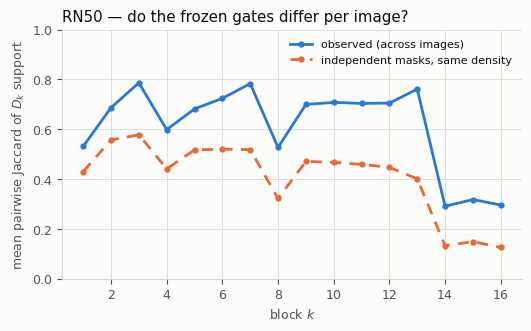

  block k    gate density    Jaccard obs    Jaccard indep    excess
---------  --------------  -------------  ---------------  --------
        1           0.602          0.531            0.43      0.101
        2           0.716          0.687            0.557     0.13
        3           0.733          0.787            0.578     0.209
        4           0.612          0.599            0.441     0.157
        5           0.682          0.682            0.517     0.165
        6           0.684          0.724            0.52      0.204
        7           0.683          0.784            0.518     0.265
        8           0.488          0.527            0.322     0.205
        9           0.64           0.7              0.471     0.229
       10           0.637          0.708            0.467     0.241
       11           0.629          0.704            0.459     0.245
       12           0.618          0.705            0.447     0.258
       13           0.572          0.761         

In [23]:
# --- (2) mask agreement across images: Jaccard on the gate supports --------------------------
def jaccard_stats(mask):
    """mask [B, ...] bool -> (mean off-diagonal Jaccard, density, expected Jaccard if independent)."""
    X = mask.reshape(mask.shape[0], -1).float()
    inter = X @ X.T
    sz = X.sum(1)
    union = sz[:, None] + sz[None, :] - inter
    J = (inter / union.clamp_min(1))
    n = J.shape[0]
    off = ~torch.eye(n, dtype=torch.bool, device=J.device)
    p = (sz / X.shape[1]).mean().item()
    return J[off].mean().item(), p, p / (2 - p)      # p/(2-p) = E[Jaccard] for independent masks


jac = np.array([jaccard_stats(g.bool()) for g in gates_g])      # [L, 3]
fig, ax = plt.subplots(figsize=(5.2, 3.2), constrained_layout=True)
x = np.arange(1, N_BLK)
ax.plot(x, jac[:, 0], color=CLR["orig"], marker="o", ms=3.5, label="observed (across images)")
ax.plot(x, jac[:, 2], color=CLR["fold"], marker="o", ms=3.5, ls=(0, (4, 3)),
        label="independent masks, same density")
ax.set_xlabel("block $k$"); ax.set_ylabel("mean pairwise Jaccard of $D_k$ support")
ax.set_ylim(0, 1); ax.legend(frameon=False, fontsize=8)
ax.set_title(f"{RN_NAME} — do the frozen gates differ per image?", loc="left", color=INK)
plt.show()

print(tabulate([[k + 1, f"{jac[k,1]:.3f}", f"{jac[k,0]:.3f}", f"{jac[k,2]:.3f}",
                 f"{jac[k,0] - jac[k,2]:+.3f}"] for k in range(N_BLK - 1)],
               headers=["block k", "gate density", "Jaccard obs", "Jaccard indep", "excess"]))
print(f"\nmean observed Jaccard = {jac[:,0].mean():.3f}   "
      f"mean independent-mask baseline = {jac[:,2].mean():.3f}")

In [24]:
# --- (3) cancellation ratio  sum_k ||c_k||  /  ||sum_k c_k|| ---------------------------------
def cancel(parts, total_vec):
    """parts [N, K, d] (components), total_vec [N, d] -> mean over images of sum||c||/||sum c||."""
    return (parts.norm(dim=-1).sum(-1) / total_vec.norm(dim=-1)).mean().item()


rows = []
A_full, P_full = RN["exact"]["attn"], RN["exact"]["mlp"]            # [N,K,H,d], [N,1,d]
M_full = total(RN, "exact")
rows.append([RN_NAME, "block (+c_pos), embedding space", N_BLK + 1,
             f"{cancel(torch.cat([A_full.sum(2), P_full], 1), M_full):.2f}"])
rows.append([RN_NAME, "block x head (+c_pos), embedding space", N_BLK * N_HEAD + 1,
             f"{cancel(torch.cat([A_full.flatten(1, 2), P_full], 1), M_full):.2f}"])
# feature-map space: the native arena of the ReLU decomposition (before pooling/projection)
fm = torch.stack([t.reshape(t.shape[0], -1) for t in contribs_g], 1)   # [B, K, C*H'*W']
rows.append([RN_NAME, "block, FEATURE-MAP space (pre-pool)", N_BLK,
             f"{cancel(fm, Z_g.reshape(Z_g.shape[0], -1)):.2f}"])
for name in RUNS:
    d = RUNS[name]["fold"]
    parts = torch.cat([d["attn"].flatten(1, 2), d["mlp"]], 1)
    rows.append([name, "head + MLP, embedding space (fold)", parts.shape[1],
                 f"{cancel(parts, total(RUNS[name], 'fold')):.2f}"])

print(tabulate(rows, headers=["model", "granularity", "# components", "cancellation ratio"]))
print("\n1.0 = perfectly aligned summands; large = the output is a small residue of opposing writes.")
del fm; torch.cuda.empty_cache()

model     granularity                               # components    cancellation ratio
--------  --------------------------------------  --------------  --------------------
RN50      block (+c_pos), embedding space                     18                 13.22
RN50      block x head (+c_pos), embedding space             545                 53.31
RN50      block, FEATURE-MAP space (pre-pool)                 17                 14.47
ViT-B-16  head + MLP, embedding space (fold)                 157                  8.93
ViT-L-14  head + MLP, embedding space (fold)                 409                 11.44

1.0 = perfectly aligned summands; large = the output is a small residue of opposing writes.


un-ablated rebuilt forward vs visual(): max abs err = 4.41e-06


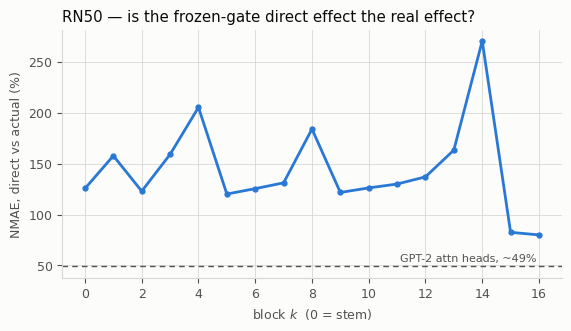

  block k    NMAE (%)    cos(direct, actual)
---------  ----------  ---------------------
        0       125.5                 -0.023
        1       157.7                  0.042
        2       122.9                 -0.032
        3       159                   -0.034
        4       205.2                  0.071
        5       120.1                 -0.029
        6       125.4                 -0.031
        7       131.1                 -0.006
        8       183.9                  0.08
        9       121.6                  0.056
       10       126.1                 -0.019
       11       129.9                 -0.024
       12       137                   -0.058
       13       163.2                 -0.162
       14       270.4                  0.274
       15        82.5                  0.569
       16        80                    0.567

mean NMAE over blocks = 143.6%   median = 129.9%   (GPT-2 attention-head reference: ~49%)


In [25]:
# --- (4) frozen-gate direct effect vs ACTUAL mean-ablation (NMAE) -----------------------------
NM_IDX = IDX_ALL[:256]
NM_IMGS = rn_images(NM_IDX)          # cached on GPU so the 17 ablation sweeps do not re-decode


@torch.no_grad()
def forward_block_ablated(visual, image, k_abl, means):
    """Real forward with block k's write replaced by its dataset mean; every ReLU recomputes.
    k_abl = -1 runs the unmodified network (used as a correctness check)."""
    with rprs._full_fp32():
        x = visual.stem(image)
        if k_abl == 0:
            x = means[0].unsqueeze(0).expand_as(x)
        idx = 1
        for layer in (visual.layer1, visual.layer2, visual.layer3, visual.layer4):
            for block in layer:
                out = block.act1(block.bn1(block.conv1(x)))
                out = block.act2(block.bn2(block.conv2(out)))
                out = block.avgpool(out)
                branch = block.bn3(block.conv3(out))
                if block.downsample is not None:
                    base, shift = rprs._downsample_linear_const(block.downsample, x)
                    write = branch + shift[None, :, None, None]
                else:
                    base, write = x, branch
                if idx == k_abl:
                    write = means[idx].unsqueeze(0).expand_as(write)
                x = torch.relu(write + base)
                idx += 1
        return visual.attnpool(x)


BS = 64
acc_raw, C_direct, M_true = None, [], []
for b0 in range(0, len(NM_IDX), BS):
    im = NM_IMGS[b0:b0 + BS]
    _, _, raw, _, _ = decompose_with_writes(visual, im)
    acc_raw = [r.sum(0) for r in raw] if acc_raw is None else [a + r.sum(0) for a, r in zip(acc_raw, raw)]
    C_direct.append(rprs.decompose_resnet_image(visual, im, vision_proj=True)["c_lh"].sum(2))
    with rprs._full_fp32():
        M_true.append(visual(im))
means_raw = [a / len(NM_IDX) for a in acc_raw]
C_direct, M_true = torch.cat(C_direct), torch.cat(M_true)
c_mean = C_direct.mean(0)

chk = torch.cat([forward_block_ablated(visual, NM_IMGS[b0:b0 + BS], -1, means_raw)
                 for b0 in range(0, len(NM_IDX), BS)])
print(f"un-ablated rebuilt forward vs visual(): max abs err = {(chk - M_true).abs().max():.2e}")
assert (chk - M_true).abs().max() < 1e-3

NM_LAB = RN["labels"][NM_IDX]
NM_BASE = top1(M_true, CLS_RN, NM_LAB)
nmae, cos_da, acc_act, acc_dir, D_ACT = [], [], [], [], []
for k in range(N_BLK):
    Mk = torch.cat([forward_block_ablated(visual, NM_IMGS[b0:b0 + BS], k, means_raw)
                    for b0 in range(0, len(NM_IDX), BS)])
    d_act = M_true - Mk                       # what actually happens
    D_ACT.append(d_act)                       # kept: the Rescale section below reuses it verbatim
    d_dir = C_direct[:, k] - c_mean[k][None]  # what the frozen-gate decomposition predicts
    nmae.append(((d_dir - d_act).abs().mean() / d_act.abs().mean()).item())
    cos_da.append(torch.nn.functional.cosine_similarity(d_dir, d_act, dim=-1).mean().item())
    # single-block ablation damage, both ways -- used against the survival curve below
    acc_act.append(top1(Mk, CLS_RN, NM_LAB))
    acc_dir.append(top1(M_true - d_dir, CLS_RN, NM_LAB))
nmae, cos_da = np.array(nmae), np.array(cos_da)
acc_act, acc_dir = np.array(acc_act), np.array(acc_dir)
D_ACT = torch.stack(D_ACT, 1)                  # [N, L+1, out]

fig, ax = plt.subplots(figsize=(5.6, 3.2), constrained_layout=True)
ax.plot(np.arange(N_BLK), nmae * 100, color=CLR["orig"], marker="o", ms=3.5, label="NMAE (%)")
ax.axhline(49, color=MUTED, lw=1.0, ls=(0, (4, 3)))
ax.annotate("GPT-2 attn heads, ~49%", (N_BLK - 1, 49), textcoords="offset points",
            xytext=(-2, 4), ha="right", fontsize=8, color=MUTED)
ax.set_xlabel("block $k$  (0 = stem)"); ax.set_ylabel("NMAE, direct vs actual (%)")
ax.set_title(f"{RN_NAME} — is the frozen-gate direct effect the real effect?", loc="left", color=INK)
plt.show()

print(tabulate([[k, f"{nmae[k]*100:.1f}", f"{cos_da[k]:+.3f}"] for k in range(N_BLK)],
               headers=["block k", "NMAE (%)", "cos(direct, actual)"]))
print(f"\nmean NMAE over blocks = {nmae.mean()*100:.1f}%   "
      f"median = {np.median(nmae)*100:.1f}%   (GPT-2 attention-head reference: ~49%)")

### Is the gating the same phenomenon as the ablation damage?

Two tests that turn "the masks matter" into a number:

1. **Survival vs. damage.** Plot the survival fraction $\|\mathrm{diag}(M_l)f_l\|/\|f_l\|$ (previous
   cell) against the *marginal* damage from ablating block $l$ **alone** — the actual re-run damage,
   not the decomposition's prediction. Both are dimensionless fractions in $[0,1]$, so they share one
   axis. If they track each other, gating and ablation sensitivity are the same phenomenon.
   The marginal (one block at a time) is the right pairing; the cumulative curve confounds blocks.
2. **All-ones control.** Re-run the *whole* block-wise ablation with every $M_l$ replaced by
   all-ones — identical propagation and identical frozen pooling weights $a^h_i(I)$, gates forced
   open. **The gap between the two curves is the masking contribution.** Note the control does not
   sum to `visual(I)` (the network really does have ReLUs), so it carries its own baseline; that is
   what makes it a control rather than a decomposition.

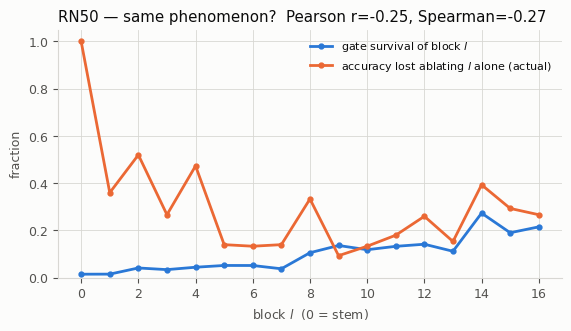

  block l    gate survival    top-1 ablating l alone (actual)    damage frac    top-1 (frozen-gate prediction)
---------  ---------------  ---------------------------------  -------------  --------------------------------
        0            0.015                               0             1                                 42.97
        1            0.015                              37.5           0.36                              36.33
        2            0.041                              28.12          0.52                              52.73
        3            0.034                              42.97          0.267                             55.47
        4            0.044                              30.86          0.473                             24.61
        5            0.052                              50.39          0.14                              57.42
        6            0.052                              50.78          0.133                             55.47
 

In [26]:
# --- (5a) survival fraction vs marginal single-block ablation damage --------------------------
dmg_act = (NM_BASE - acc_act) / NM_BASE          # fraction of accuracy lost by ablating block l alone
r_pear = float(np.corrcoef(surv_norm, dmg_act)[0, 1])
rk = lambda v: np.argsort(np.argsort(v))
r_spear = float(np.corrcoef(rk(surv_norm), rk(dmg_act))[0, 1])

fig, ax = plt.subplots(figsize=(5.6, 3.2), constrained_layout=True)
x = np.arange(N_BLK)
ax.plot(x, surv_norm, color=CLR["orig"], marker="o", ms=3.5, label="gate survival of block $l$")
ax.plot(x, dmg_act, color=CLR["fold"], marker="o", ms=3.5,
        label="accuracy lost ablating $l$ alone (actual)")
ax.set_xlabel("block $l$  (0 = stem)"); ax.set_ylabel("fraction")
ax.set_ylim(0, 1.05); ax.legend(frameon=False, fontsize=8)
ax.set_title(f"{RN_NAME} — same phenomenon?  Pearson r={r_pear:+.2f}, Spearman={r_spear:+.2f}",
             loc="left", color=INK)
plt.show()

print(tabulate([[k, f"{surv_norm[k]:.3f}", f"{acc_act[k]:.2f}", f"{dmg_act[k]:.3f}",
                 f"{acc_dir[k]:.2f}"] for k in range(N_BLK)],
               headers=["block l", "gate survival", "top-1 ablating l alone (actual)",
                        "damage frac", "top-1 (frozen-gate prediction)"]))
print(f"\nbaseline {NM_BASE:.2f}% on N={len(NM_IDX)}   "
      f"corr(survival, damage): Pearson {r_pear:+.3f}, Spearman {r_spear:+.3f}")

real-gate control rebuild vs saved embedding: max abs err = 6.57e-05


baselines (0 blocks ablated): real gates 58.70%   all-ones control 0.20%


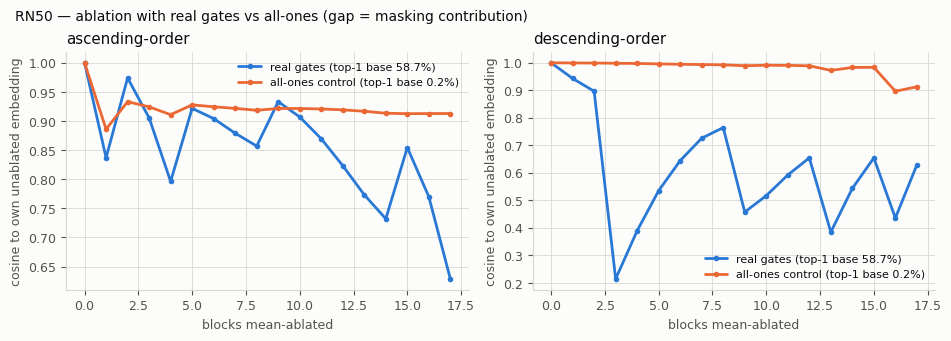

order         # blocks ablated    real top-1    all-ones top-1    real cos    all-ones cos    gap (masking)
----------  ------------------  ------------  ----------------  ----------  --------------  ---------------
ascending                    1          44.3               0.2      0.837           0.886           -0.049
ascending                    4          42.6               0.2      0.7962          0.9109          -0.1147
ascending                    8          47.3               0.2      0.857           0.9185          -0.0615
ascending                   12          43.7               0.1      0.8233          0.9192          -0.0959
ascending                   17           0.1               0.1      0.6288          0.9128          -0.2841
descending                   1          54.7               0.2      0.9431          0.9994          -0.0564
descending                   4           0.3               0.2      0.3895          0.9975          -0.608
descending                   8

In [27]:
# --- (5b) all-ones control: same ablation with every gate forced open -------------------------
@torch.no_grad()
def block_components_gated_and_open(sel_idx, batch=32):
    """Block components in embedding space, real gates vs gates forced open.

    Everything else is held fixed -- same images, same propagation, and the frozen pooling weights
    a^h_i(I) are taken from the REAL feature map in both cases -- so the only difference is masking.
    Each is normalized by the norm of its own total, matching how the saved activations are stored.
    """
    real, ctrl = [], []
    for b0 in range(0, len(sel_idx), batch):
        im = rn_images(sel_idx[b0:b0 + batch])
        cg, ng, _, _, Z = decompose_with_writes(visual, im)
        for lst, sink in ((cg, real), (ng, ctrl)):
            c_lh, c_p, _ = rprs.attnpool_split(visual.attnpool, lst, Z, check=False, vision_proj=True)
            blk = c_lh.sum(2)                              # [B, L+1, out]
            tot = blk.sum(1) + c_p
            n = tot.norm(dim=-1).clamp_min(1e-12)
            sink.append((blk / n[:, None, None], c_p / n[:, None]))
    return tuple({"blk": torch.cat([b for b, _ in s]), "pos": torch.cat([p for _, p in s])}
                 for s in (real, ctrl))


CTRL_IDX = IDX_ALL
REAL_C, OPEN_C = block_components_gated_and_open(CTRL_IDX)
lab_s = RN["labels"][CTRL_IDX]


def as_run(d):
    return {"exact": {"attn": d["blk"][:, :, None, :], "mlp": d["pos"][:, None, :],
                      "bias": torch.zeros_like(d["pos"])},
            "emb": d["blk"].sum(1) + d["pos"], "labels": lab_s}


runs_c = {"real gates": as_run(REAL_C), "all-ones control": as_run(OPEN_C)}
print("real-gate control rebuild vs saved embedding: max abs err = "
      f"{(runs_c['real gates']['emb'] - RN['emb'][CTRL_IDX]).abs().max():.2e}")

ctrl_curves, bases = {}, {}
for tag, r in runs_c.items():
    bases[tag] = top1(r["emb"], CLS_RN, lab_s)
    for order in ("ascending", "descending"):
        ctrl_curves[(tag, order)] = ablation_curve(r, "exact", block_groups(Lp1, 1, order), CLS_RN)

print(f"baselines (0 blocks ablated): real gates {bases['real gates']:.2f}%   "
      f"all-ones control {bases['all-ones control']:.2f}%")

# NOTE the control is DEGENERATE as an accuracy comparison: forcing every gate open destroys the
# model BEFORE any ablation, so "fraction of accuracy lost" has no usable denominator. That is
# itself the headline result. The gap is still readable in a scale-free geometric metric, so we
# compare cosine-to-own-unablated-embedding, which is well defined for both.
CC = {"real gates": "#2a78d6", "all-ones control": "#eb6834"}
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3), constrained_layout=True)
for ax, order in zip(axes, ("ascending", "descending")):
    for tag in CC:
        ns, acc, cos = ctrl_curves[(tag, order)]
        ax.plot(np.arange(len(cos)), cos, color=CC[tag], marker="o", ms=3,
                label=f"{tag} (top-1 base {bases[tag]:.1f}%)", solid_capstyle="round")
    ax.set_xlabel("blocks mean-ablated"); ax.set_ylabel("cosine to own unablated embedding")
    ax.set_title(f"{order}-order", loc="left", color=INK)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"{RN_NAME} — ablation with real gates vs all-ones (gap = masking contribution)",
             x=0.01, ha="left", fontsize=10, color=INK)
plt.show()

rows = []
for order in ("ascending", "descending"):
    ar, cr = ctrl_curves[("real gates", order)][1:]
    ao, co = ctrl_curves[("all-ones control", order)][1:]
    for i in (1, 4, 8, 12, N_BLK):
        rows.append([order, i, f"{ar[i]:.2f}", f"{ao[i]:.2f}", f"{cr[i]:.4f}", f"{co[i]:.4f}",
                     f"{cr[i] - co[i]:+.4f}"])
print(tabulate(rows, headers=["order", "# blocks ablated", "real top-1", "all-ones top-1",
                              "real cos", "all-ones cos", "gap (masking)"]))
del REAL_C, OPEN_C, runs_c; torch.cuda.empty_cache()

### Does a finer $(k,n)$ granularity change the ablation?

Keeping the **block** and **neuron** indices while summing out heads and tokens gives
$\boldsymbol r^{n,k}=\sum_h\sum_i \boldsymbol r^{n,h,k}_i$, then we mean-ablate per layer in both
topological orders again.

**It cannot differ, and the reason is worth stating.** Mean-ablation is *linear* in the components:
ablating a set $S$ replaces $\sum_{k\in S} c_k(I)$ by $\sum_{k\in S}\bar c_k$, and
$\sum_n \overline{\boldsymbol r^{n,k}} = \overline{\sum_n \boldsymbol r^{n,k}} = \bar{\boldsymbol r}^k$.
So *any* regrouping that ablates the **same set** of terms produces the identical embedding —
granularity only buys something when it lets you ablate a set you could not name before.

Below: (i) verify $\sum_n \boldsymbol r^{n,k} = \boldsymbol r^{k}$ and that the two ablation curves
coincide to machine precision, then (ii) do the thing the finer granularity *does* enable — ablate
only the **top-10% highest-norm neurons** of each block, which is not expressible at block level.

In [28]:
KN_IDX = IDX_ALL                                  # 1000 images, one per class
NEU_CHUNK, RANK_N = 128, 128                      # neuron chunk; images used for neuron ranking


@torch.no_grad()
def rn_decompose_subset(sel_idx, batch=32):
    """a [N,H,K+1], c [L+1,K+1,N,C], c_pos [N,out] over an image subset (batched: contribs are big)."""
    N = len(sel_idx)
    a_all = torch.empty(N, H, K1, device=DEVICE)
    c_all = torch.empty(Lp1, K1, N, C, device=DEVICE)
    p_all = torch.empty(N, OUT, device=DEVICE)
    for b0 in range(0, N, batch):
        im = rn_images(sel_idx[b0:b0 + batch])
        a_b, c_b, _, p_b = decompose_resnet_fine(visual, im)
        a_all[b0:b0 + im.shape[0]] = a_b
        c_all[:, :, b0:b0 + im.shape[0], :] = c_b
        p_all[b0:b0 + im.shape[0]] = p_b
    return a_all, c_all, p_all


def kn_components(a_, c_, k, n_idx, img=slice(None)):
    """r^{n,k} for a neuron slice (optionally a subset of images) -> [B, |n|, out].
    Heads and tokens are summed out; the neuron and block indices are kept."""
    with rprs._full_fp32():          # TF32 (~1e-3 rel) would swamp the exactness checks below
        v = torch.einsum("bhi,ibn->bhn", a_[img], c_[k][:, img, n_idx])
        return torch.einsum("bhn,hno->bno", v, W_VO[:, n_idx])


def kn_masked_sum(a_, c_, k, mask):
    """sum_{n in mask} r^{n,k} -> [B, out], via a masked contraction (never materializes per-n)."""
    with rprs._full_fp32():
        v = torch.einsum("bhi,ibn->bhn", a_, c_[k] * mask[None, None, :])
        return torch.einsum("bhn,hno->bo", v, W_VO)


a_s, c_s, pos_s = rn_decompose_subset(KN_IDX)
ALL_N = torch.ones(C, device=DEVICE)
blk_unnorm = torch.stack([kn_masked_sum(a_s, c_s, k, ALL_N) for k in range(Lp1)], 1)  # [N, L+1, out]
norm_s = (blk_unnorm.sum(1) + pos_s).norm(dim=-1)                                     # ||M(I)||

# (i) verify  sum_n r^{n,k} == r^k  and that per-neuron means sum to the block mean
blk_kn = blk_unnorm / norm_s[:, None, None]
blk_saved = RN["exact"]["attn"][KN_IDX].sum(2)                                  # [N, L+1, out]
e_abs = (blk_kn - blk_saved).abs().max().item()
# ~1e-3 here is cross-IMPLEMENTATION agreement, not error: this path contracts (n, h, i) in a
# completely different order from attnpool_split, and with a cancellation ratio around 11 the
# fp32 rounding of the surviving residue is amplified accordingly. The claim actually being
# tested -- linearity of the mean -- is checked below within a single summation order (~1e-5).
print(f"sum_n r^(n,k)  vs saved block component : max abs err = {e_abs:.2e}  "
      f"(rel to max |component| {blk_saved.abs().max():.2f}: {e_abs/blk_saved.abs().max():.1e}, "
      f"fp32 cross-implementation)")
assert e_abs < 5e-3, "the (k,n) path does not reproduce the block components"

mean_from_neurons = torch.zeros(Lp1, OUT, device=DEVICE)
neu_norm = torch.zeros(Lp1, C, device=DEVICE)
rank_img = slice(0, min(RANK_N, len(KN_IDX)))
for k in range(Lp1):
    for n0 in range(0, C, NEU_CHUNK):
        sl = slice(n0, n0 + NEU_CHUNK)
        r = kn_components(a_s, c_s, k, sl) / norm_s[:, None, None]      # [N, |n|, out]
        mean_from_neurons[k] += r.mean(0).sum(0)                         # sum_n mean_I r^{n,k}
        neu_norm[k, sl] = kn_components(a_s, c_s, k, sl, img=rank_img).norm(dim=-1).mean(0)
        del r
print(f"sum_n mean_I r^(n,k)  vs  mean_I r^k     : max abs err = "
      f"{(mean_from_neurons - blk_saved.mean(0)).abs().max():.2e}   (linearity of mean-ablation)")
torch.cuda.empty_cache()

sum_n r^(n,k)  vs saved block component : max abs err = 4.33e-03  (rel to max |component| 1.50: 2.9e-03, fp32 cross-implementation)


sum_n mean_I r^(n,k)  vs  mean_I r^k     : max abs err = 5.81e-06   (linearity of mean-ablation)


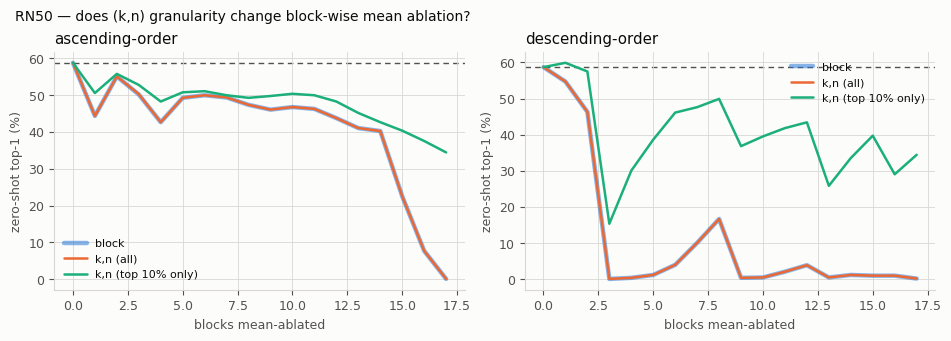

N=1000 (1 image/class), baseline 58.70%, top-10% = 205/2048 neurons per block
order         # blocks ablated    block gran.    (k,n) gran.    difference    (k,n) top-10% only
----------  ------------------  -------------  -------------  ------------  --------------------
ascending                    1           44.3           44.3             0                  50.5
ascending                    4           42.6           42.6             0                  48.2
ascending                    8           47.3           47.3             0                  49.2
ascending                   12           43.7           43.7             0                  48.2
ascending                   17            0.1            0.1             0                  34.4
descending                   1           54.7           54.7             0                  59.9
descending                   4            0.3            0.3             0                  30
descending                   8           16.6      

In [29]:
# top-10% highest-norm neurons per block; split each block into [top-10%, rest] along the H axis
TOP_FRAC = 0.10
n_top = int(round(TOP_FRAC * C))
top_mask = torch.zeros(Lp1, C, device=DEVICE)
top_mask.scatter_(1, neu_norm.topk(n_top, dim=1).indices, 1.0)

attn_split = torch.empty(len(KN_IDX), Lp1, 2, OUT, device=DEVICE)
for k in range(Lp1):
    tp = kn_masked_sum(a_s, c_s, k, top_mask[k]) / norm_s[:, None]
    attn_split[:, k, 0] = tp
    attn_split[:, k, 1] = blk_kn[:, k] - tp

RN_S = {"exact": {"attn": RN["exact"]["attn"][KN_IDX], "mlp": RN["exact"]["mlp"][KN_IDX],
                  "bias": torch.zeros(len(KN_IDX), OUT, device=DEVICE)},
        "emb": RN["emb"][KN_IDX], "labels": RN["labels"][KN_IDX]}
RN_KN = {"exact": {"attn": attn_split, "mlp": RN["exact"]["mlp"][KN_IDX],
                   "bias": torch.zeros(len(KN_IDX), OUT, device=DEVICE)},
         "emb": RN["emb"][KN_IDX], "labels": RN["labels"][KN_IDX]}

curves = {}
for order in ("ascending", "descending"):
    curves[("block", order)] = ablation_curve(RN_S, "exact", block_groups(N_BLK, N_HEAD, order), CLS_RN)
    curves[("k,n (all)", order)] = ablation_curve(RN_KN, "exact", block_groups(Lp1, 2, order), CLS_RN)
    ks = range(Lp1) if order == "ascending" else range(Lp1 - 1, -1, -1)
    curves[("k,n (top 10% only)", order)] = ablation_curve(
        RN_KN, "exact", [([(k, 0)], []) for k in ks], CLS_RN)

base_s = top1(RN_S["emb"], CLS_RN, RN_S["labels"])
SER = {"block": "#2a78d6", "k,n (all)": "#eb6834", "k,n (top 10% only)": "#1baf7a"}
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3), constrained_layout=True)
for ax, order in zip(axes, ("ascending", "descending")):
    ax.axhline(base_s, color=MUTED, lw=1.0, ls=(0, (4, 3)), zorder=1)
    for i, tag in enumerate(SER):
        ns, acc, _ = curves[(tag, order)]
        ax.plot(np.arange(len(acc)), acc, color=SER[tag], label=tag, zorder=3 + i,
                lw=3.2 if tag == "block" else 1.8, alpha=0.55 if tag == "block" else 1.0,
                solid_capstyle="round")
    ax.set_xlabel("blocks mean-ablated"); ax.set_ylabel("zero-shot top-1 (%)")
    ax.set_title(f"{order}-order", loc="left", color=INK)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"{RN_NAME} — does (k,n) granularity change block-wise mean ablation?", x=0.01,
             ha="left", fontsize=10, color=INK)
plt.show()

rows, dmax = [], 0.0
for order in ("ascending", "descending"):
    ab, af, at = (curves[(t, order)][1] for t in SER)
    dmax = max(dmax, np.abs(ab - af).max())
    for i in (1, 4, 8, 12, N_BLK):
        rows.append([order, i, f"{ab[i]:.2f}", f"{af[i]:.2f}", f"{af[i]-ab[i]:+.3f}", f"{at[i]:.2f}"])
print(f"N={len(KN_IDX)} (1 image/class), baseline {base_s:.2f}%, "
      f"top-10% = {n_top}/{C} neurons per block")
print(tabulate(rows, headers=["order", "# blocks ablated", "block gran.", "(k,n) gran.",
                              "difference", "(k,n) top-10% only"]))
print(f"\nmax |block granularity - (k,n) granularity| over BOTH full sweeps = {dmax:.3g} pts")

---
## Part 2h — zero ablation vs mean ablation

Mean ablation replaces $c_k$ by $\bar c_k$; zero ablation removes it. Both are exact in the
decomposition, which is linear in the components, so the only thing that changes is the reference
the ablation moves toward — and the two references are not interchangeable: $\bar c_k \neq 0$, so
mean ablation leaves the dataset-average write in place where zero ablation deletes it.

Four curves per topological order, all on the same 256 images so the baselines match:

| curve | what it does |
| --- | --- |
| decomposition, mean | subtract $c_k(I)-\bar c_k$ from the embedding |
| decomposition, zero | subtract $c_k(I)$ |
| **actual, mean** | re-run the network with block $k$'s write set to $\bar F_k$ |
| **actual, zero** | re-run the network with block $k$'s write set to $0$ |

The two "actual" curves are the ground truth. Given the NMAE result above the decomposition curves
are not causal claims; they are plotted to show the size of the gap under each reference.

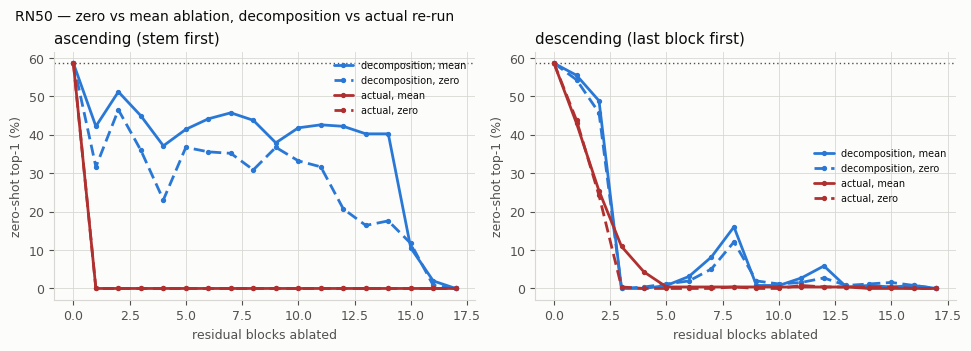

RN50 baseline = 58.59%  (N=256)
order         # blocks ablated    decomp mean    decomp zero    actual mean    actual zero
----------  ------------------  -------------  -------------  -------------  -------------
ascending                    1          42.19          31.64           0              0
ascending                    4          37.11          23.05           0              0
ascending                    8          43.75          30.86           0              0
ascending                   12          42.19          20.7            0              0
ascending                   17           0              0              0              0
descending                   1          55.47          54.3           42.97          43.75
descending                   4           0              0.39           4.3            0
descending                   8          16.02          12.11           0.39           0.39
descending                  12           5.86           2.73           0.39 

In [30]:
# --- block-wise zero vs mean ablation, decomposition and actual re-run ------------------------
RN_STAGES = (visual.layer1, visual.layer2, visual.layer3, visual.layer4)


@torch.no_grad()
def forward_blocks_ablated(visual, image, k_set, vals):
    """Real forward with the write of EVERY block in k_set replaced by vals[k]; ReLUs recompute."""
    with rprs._full_fp32():
        x = visual.stem(image)
        if 0 in k_set:
            x = vals[0].unsqueeze(0).expand_as(x)
        idx = 1
        for layer in RN_STAGES:
            for block in layer:
                out = block.act1(block.bn1(block.conv1(x)))
                out = block.act2(block.bn2(block.conv2(out)))
                out = block.avgpool(out)
                branch = block.bn3(block.conv3(out))
                if block.downsample is not None:
                    base, shift = rprs._downsample_linear_const(block.downsample, x)
                    write = branch + shift[None, :, None, None]
                else:
                    base, write = x, branch
                if idx in k_set:
                    write = vals[idx].unsqueeze(0).expand_as(write)
                x = torch.relu(write + base)
                idx += 1
        return visual.attnpool(x)


def actual_curve(order, vals, batch=64):
    """Cumulative curve from re-running the network, one block added to the ablated set per step."""
    ks = list(range(N_BLK)) if order == "ascending" else list(range(N_BLK - 1, -1, -1))
    accs, coss = [], []
    for i in range(len(ks) + 1):
        kset = set(ks[:i])
        M = torch.cat([forward_blocks_ablated(visual, NM_IMGS[b0:b0 + batch], kset, vals)
                       for b0 in range(0, len(NM_IDX), batch)])
        accs.append(top1(M, CLS_RN, NM_LAB))
        coss.append(torch.nn.functional.cosine_similarity(M, M_true, dim=-1).mean().item())
    return np.arange(len(ks) + 1), np.array(accs), np.array(coss)


ZEROS_RAW = [torch.zeros_like(m) for m in means_raw]
# same 256 images as the actual re-runs, so the two families share a baseline
RN_NM = {"exact": {k: v[NM_IDX] for k, v in RN["exact"].items()},
         "emb": RN["emb"][NM_IDX], "labels": NM_LAB}

ZM = {}
for o in ("ascending", "descending"):
    grp = block_groups(N_BLK, N_HEAD, o)
    for mode in ("mean", "zero"):
        ns, acc, cos = ablation_curve(RN_NM, "exact", grp, CLS_RN, mode=mode)
        ZM[("decomposition", mode, o)] = (ns // N_HEAD, acc, cos)
    ZM[("actual", "mean", o)] = actual_curve(o, means_raw)
    ZM[("actual", "zero", o)] = actual_curve(o, ZEROS_RAW)

SRC_CLR = {"decomposition": "#2a78d6", "actual": "#b03030"}
MODE_LS2 = {"mean": "-", "zero": (0, (4, 2))}
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), constrained_layout=True)
for ax, o in zip(axes, ("ascending", "descending")):
    ax.axhline(NM_BASE, color=MUTED, lw=1.0, ls=(0, (1, 2)), zorder=1)
    for src in ("decomposition", "actual"):
        for mode in ("mean", "zero"):
            x, acc, _ = ZM[(src, mode, o)]
            ax.plot(x, acc, color=SRC_CLR[src], ls=MODE_LS2[mode], marker="o", ms=2.8, zorder=3,
                    label=f"{src}, {mode}", solid_capstyle="round")
    ax.set_xlabel("residual blocks ablated"); ax.set_ylabel("zero-shot top-1 (%)")
    ax.set_title(f"{o} (stem first)" if o == "ascending" else f"{o} (last block first)",
                 loc="left", color=INK)
    ax.legend(frameon=False, fontsize=7)
fig.suptitle(f"{RN_NAME} — zero vs mean ablation, decomposition vs actual re-run", x=0.01,
             ha="left", fontsize=10, color=INK)
plt.show()

rows = []
for o in ("ascending", "descending"):
    for i in (1, 4, 8, 12, N_BLK):
        rows.append([o, i] + [f"{ZM[(s, m, o)][1][i]:.2f}"
                              for s in ("decomposition", "actual") for m in ("mean", "zero")])
print(f"{RN_NAME} baseline = {NM_BASE:.2f}%  (N={len(NM_IDX)})")
print(tabulate(rows, headers=["order", "# blocks ablated", "decomp mean", "decomp zero",
                              "actual mean", "actual zero"]))
for o in ("ascending", "descending"):
    dm, dz = ZM[("decomposition", "mean", o)][1], ZM[("decomposition", "zero", o)][1]
    am, az = ZM[("actual", "mean", o)][1], ZM[("actual", "zero", o)][1]
    print(f"\n{o}: mean |decomposition - actual| = {np.abs(dm-am).mean():.2f} pts (mean-abl), "
          f"{np.abs(dz-az).mean():.2f} pts (zero-abl)   |   "
          f"actual zero vs actual mean, mean gap = {np.abs(az-am).mean():.2f} pts")
torch.cuda.empty_cache()

---
## Part 2f — DeepLIFT-Rescale multipliers at the mean-ablation reference

The frozen 0/1 gate is the multiplier **at reference $0$**. Mean ablation does not move the network
to $0$, it moves it to the mean, so the object that actually chains is the *soft* multiplier

$$m_l \;=\; \frac{\mathrm{ReLU}(w_l)-\mathrm{ReLU}(\hat w_l)}{w_l-\hat w_l}\;\in\;[0,1],$$

which equals $1$ when both runs are on the positive side, $0$ when both are on the negative side, and
lands strictly inside $(0,1)$ exactly at the coordinates where the ablation **flips a gate** — the
coordinates the frozen mask cannot see.

**Which reference.** A multiplier needs a *pair* of runs. Computing it against each ablation's own
counterfactual makes the prediction exact by telescoping — and useless, since it needs the re-run we
are trying to avoid. The testable version uses **one fixed reference for all blocks**: the trajectory
in which *every* block write is replaced by its dataset mean,

$$\hat z_0=\bar F_0,\qquad \hat w_l=\bar F_l+A_l\hat z_{l-1},\qquad \hat z_l=\mathrm{ReLU}(\hat w_l),$$

which is image-independent by construction and is exactly the point block-wise mean ablation moves
toward. Writing $\Delta z_l=z_l-\hat z_l$ and $\Delta F_l = F_l(x)-\bar F_l$, the same recursion as
before goes through with $D_l\to m_l$:

$$\Delta z_l = m_l\odot\bigl(\Delta F_l + A_l\,\Delta z_{l-1}\bigr)
\;\;\Longrightarrow\;\;
Z(x)-\hat Z \;=\; \sum_{k}\tilde G_k(x)\,\Delta F_k,\qquad \tilde G_k=\tilde G_{k+1}A_{k+1}m_k .$$

This is a **completeness identity that must hold to machine precision** — it is the bug check, and it
is checked below. Everything else about the pipeline is held fixed: same images, same frozen pooling
weights $a^h_i(I)$ taken from the real feature map, same $\bar F_k$. The *only* changed variable is
$D_l \to m_l$, so the NMAE difference against the frozen-gate run is attributable to nothing else.

Note the identity lives at the **feature-map** level. The attention pool is frozen-softmax, not
linear, so it contributes its own error on top; that error is isolated below as the full-ablation
residual, separately from the gate error.

**Read NMAE against 100%, not 0%.** NMAE $=100\%$ is exactly what the null predictor
$d_{\text{pred}}=0$ scores — "this block does nothing". A method above that line is *worse than
saying nothing*; at it, no better. That is the bar, and the frozen-gate run at 143.6% is on the
wrong side of it.

In [31]:
# --- (6) Rescale multipliers against the fully mean-ablated reference trajectory ---------------
@torch.no_grad()
def null_trajectory(visual, means):
    """The reference run: EVERY block write replaced by its dataset mean.

    Image-independent by construction (nothing in it depends on x), so it is a single trajectory.
    Returns the pre-activations w_hat_l (index 0 unused, blocks 1..L) and the final feature map.
    """
    with rprs._full_fp32():
        z = means[0].unsqueeze(0)                       # mean-ablated stem output, [1,C,H,W]
        pre_hat, idx = [None], 1
        for layer in RN_STAGES:
            for block in layer:
                ds = block.downsample
                base = rprs._downsample_linear_only(ds, z) if ds is not None else z
                w = means[idx].unsqueeze(0) + base      # means[idx] already carries the shortcut BN shift
                pre_hat.append(w)
                z = torch.relu(w)
                idx += 1
    return pre_hat, z


@torch.no_grad()
def decompose_rescale(visual, image, means, pre_hat, eps=1e-6):
    """DeepLIFT-Rescale decomposition of Z(x) - Z_null against the fixed reference trajectory.

    Identical to `decompose_with_writes` except (i) the frozen 0/1 gate D_l is replaced by the soft
    multiplier m_l and (ii) the propagated payload is the write DIFFERENCE F_l(x) - mean F_l.
    Where |w - w_hat| < eps the multiplier is taken to be the derivative 1[w > 0] (the limit).
    """
    with rprs._full_fp32():
        x = visual.stem(image)
        d = [x - means[0][None]]                        # block 0 = stem
        mults, idx = [], 1
        for layer in RN_STAGES:
            for block in layer:
                out = block.act1(block.bn1(block.conv1(x)))
                out = block.act2(block.bn2(block.conv2(out)))
                out = block.avgpool(out)
                branch = block.bn3(block.conv3(out))
                ds = block.downsample
                if ds is not None:
                    lin, shift = rprs._downsample_linear_const(ds, x)
                    write = branch + shift[None, :, None, None]
                    pre = write + lin
                    d = [rprs._downsample_linear_only(ds, t) for t in d]
                else:
                    write, pre = branch, branch + x
                den = pre - pre_hat[idx]
                small = den.abs() < eps
                m = (torch.relu(pre) - torch.relu(pre_hat[idx])) / torch.where(
                    small, torch.ones_like(den), den)
                m = torch.where(small, (pre > 0).to(pre.dtype), m)
                d = [m * t for t in d]
                d.append(m * (write - means[idx][None]))
                mults.append(m)
                x = torch.relu(pre)
                idx += 1
    return d, mults, x


PRE_HAT, Z_NULL = null_trajectory(visual, means_raw)
with rprs._full_fp32():
    M_NULL = visual.attnpool(Z_NULL)                    # NN at the reference = full mean ablation

# completeness of the Rescale decomposition, at the feature-map level where it is an identity
im0 = NM_IMGS[:BS]
d0, m0, Z0 = decompose_rescale(visual, im0, means_raw, PRE_HAT)
res = (torch.stack(d0, 0).sum(0) - (Z0 - Z_NULL)).abs().max().item()
scale = (Z0 - Z_NULL).abs().max().item()
print(f"completeness  sum_k Gt_k dF_k  vs  Z(x) - Z_null : max abs err = {res:.2e} "
      f"(scale {scale:.2f}, rel {res/scale:.1e})")
assert res / scale < 1e-4, "the Rescale decomposition is not complete -- bug, not a finding"

mfrac = torch.cat([(mm > 0).float().flatten() * (mm < 1).float().flatten() for mm in m0]).mean()
print(f"multiplier is strictly inside (0,1) at {mfrac*100:.2f}% of coordinates "
      f"-- these are exactly the gates the ablation flips, invisible to the frozen mask")
del d0, m0, Z0; torch.cuda.empty_cache()

completeness  sum_k Gt_k dF_k  vs  Z(x) - Z_null : max abs err = 4.08e-05 (scale 40.62, rel 1.0e-06)
multiplier is strictly inside (0,1) at 20.67% of coordinates -- these are exactly the gates the ablation flips, invisible to the frozen mask


full ablation (all blocks): NMAE = 50.9%  <- frozen-softmax pooling error only


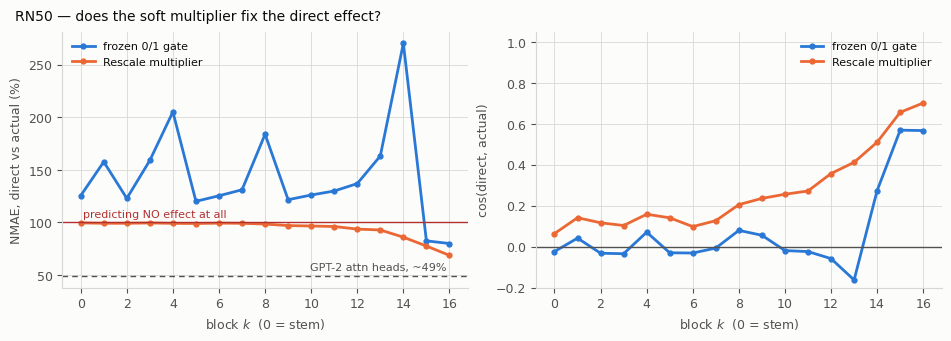

  block k    NMAE hard (%)    NMAE soft (%)    cos hard    cos soft    top-1 actual    top-1 hard pred    top-1 soft pred
---------  ---------------  ---------------  ----------  ----------  --------------  -----------------  -----------------
        0            125.5             99.6      -0.023       0.064            0                 42.97              57.42
        1            157.7             99.2       0.042       0.142           37.5               36.33              58.2
        2            122.9             99.2      -0.032       0.117           28.12              52.73              59.77
        3            159               99.5      -0.034       0.104           42.97              55.47              59.38
        4            205.2             99.2       0.071       0.159           30.86              24.61              58.59
        5            120.1             99        -0.029       0.141           50.39              57.42              57.81
        6            125.

In [32]:
# --- (6b) soft-multiplier direct effect vs the SAME actual ablations ---------------------------
# D_ACT (from cell 4) is reused verbatim, so hard and soft are scored against identical ground truth.
D_SOFT = []
for b0 in range(0, len(NM_IDX), BS):
    d, _, Zr = decompose_rescale(visual, NM_IMGS[b0:b0 + BS], means_raw, PRE_HAT)
    # pooled with the REAL run's frozen weights a^h_i(I) -- the same pooling the frozen-gate run used
    c_lh, _, _ = rprs.attnpool_split(visual.attnpool, d, Zr, check=False, vision_proj=True)
    D_SOFT.append(c_lh.sum(2))                          # [B, L+1, out]
    del d, c_lh
D_SOFT = torch.cat(D_SOFT)
torch.cuda.empty_cache()

# (i) full ablation: sum_k of the predictions vs the true M(x) - M_null. The gates are exact here by
#     construction, so whatever error remains is the FROZEN-SOFTMAX pool alone -- the error floor.
d_full_pred, d_full_act = D_SOFT.sum(1), M_true - M_NULL
nmae_pool = ((d_full_pred - d_full_act).abs().mean() / d_full_act.abs().mean()).item()
print(f"full ablation (all blocks): NMAE = {nmae_pool*100:.1f}%  <- frozen-softmax pooling error only")

# (ii) per-block, the real test: one fixed multiplier set predicting each single-block ablation
nmae_s, cos_s, acc_soft = [], [], []
for k in range(N_BLK):
    d_act, d_sft = D_ACT[:, k], D_SOFT[:, k]
    nmae_s.append(((d_sft - d_act).abs().mean() / d_act.abs().mean()).item())
    cos_s.append(torch.nn.functional.cosine_similarity(d_sft, d_act, dim=-1).mean().item())
    acc_soft.append(top1(M_true - d_sft, CLS_RN, NM_LAB))
nmae_s, cos_s, acc_soft = np.array(nmae_s), np.array(cos_s), np.array(acc_soft)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3), constrained_layout=True)
x = np.arange(N_BLK)
axes[0].plot(x, nmae * 100, color=CLR["orig"], marker="o", ms=3.5, label="frozen 0/1 gate")
axes[0].plot(x, nmae_s * 100, color=CLR["fold"], marker="o", ms=3.5, label="Rescale multiplier")
axes[0].axhline(100, color="#b03030", lw=1.0)
axes[0].annotate("predicting NO effect at all", (0, 100), textcoords="offset points",
                 xytext=(2, 4), ha="left", fontsize=8, color="#b03030")
axes[0].axhline(49, color=MUTED, lw=1.0, ls=(0, (4, 3)))
axes[0].annotate("GPT-2 attn heads, ~49%", (N_BLK - 1, 49), textcoords="offset points",
                 xytext=(-2, 4), ha="right", fontsize=8, color=MUTED)
axes[0].set_ylabel("NMAE, direct vs actual (%)")
axes[1].plot(x, cos_da, color=CLR["orig"], marker="o", ms=3.5, label="frozen 0/1 gate")
axes[1].plot(x, cos_s, color=CLR["fold"], marker="o", ms=3.5, label="Rescale multiplier")
axes[1].axhline(0, color=MUTED, lw=1.0); axes[1].set_ylim(-0.2, 1.05)
axes[1].set_ylabel("cos(direct, actual)")
for ax in axes:
    ax.set_xlabel("block $k$  (0 = stem)"); ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"{RN_NAME} — does the soft multiplier fix the direct effect?", x=0.01, ha="left",
             fontsize=10, color=INK)
plt.show()

print(tabulate([[k, f"{nmae[k]*100:.1f}", f"{nmae_s[k]*100:.1f}", f"{cos_da[k]:+.3f}",
                 f"{cos_s[k]:+.3f}", f"{acc_act[k]:.2f}", f"{acc_dir[k]:.2f}", f"{acc_soft[k]:.2f}"]
                for k in range(N_BLK)],
               headers=["block k", "NMAE hard (%)", "NMAE soft (%)", "cos hard", "cos soft",
                        "top-1 actual", "top-1 hard pred", "top-1 soft pred"]))
print(f"\nN={len(NM_IDX)}, baseline {NM_BASE:.2f}%")
print(f"mean NMAE : frozen gate {nmae.mean()*100:.1f}%  ->  Rescale {nmae_s.mean()*100:.1f}%   "
      f"(median {np.median(nmae)*100:.1f}% -> {np.median(nmae_s)*100:.1f}%)")
print(f"mean cos  : frozen gate {cos_da.mean():+.3f}  ->  Rescale {cos_s.mean():+.3f}")
print(f"mean |top-1 prediction error| : frozen {np.abs(acc_dir-acc_act).mean():.2f} pts  ->  "
      f"Rescale {np.abs(acc_soft-acc_act).mean():.2f} pts")
# NMAE = 100% is the null predictor d_pred = 0 ("this block does nothing"). Above it a method is
# worse than saying nothing; at it, no better. That, not 0%, is the line these curves must clear.
print(f"blocks where the prediction beats the null predictor (NMAE < 100%): "
      f"frozen {int((nmae < 1).sum())}/{N_BLK}  ->  Rescale {int((nmae_s < 1).sum())}/{N_BLK}   "
      f"| pooling-only floor (exact gates, full ablation) = {nmae_pool*100:.1f}%")

---
## Part 2g — the image-independent gauge: folding $\bar G_l$

Caveat 3 says a cross-image *role* claim needs the gate to behave like a scalar gauge. The clean test
is to replace the per-image operator $G_l(x)$ in the **read-out** by the image-independent
$\bar G_l = \mathbb{E}_I[D_l]$ — a fixed soft mask per coordinate — while the network itself keeps
running with its true ReLUs. If the folded gauge preserves the zero-shot behaviour, the per-image
map objection costs nothing and $\bar G_l$ can be folded into the probe once and for all. Three
points on the same axis, all with identical propagation and identical frozen pooling:

| read-out operator | what it assumes |
| --- | --- |
| $G_l(x)$, real gates | nothing; this is the exact decomposition |
| $\bar G_l = \mathbb{E}[D_l]$ | the gate is an image-independent attenuation |
| $\mathbf 1$, all-ones | there is no gate at all (the control from Part 2e) |

The same $\bar G_l$ also gives the factorized baseline $\bar G_k \bar F_k$ that Step 4 forbids using
as an ablation value. It is still worth *measuring*: the gap to the honest $\overline{G_k F_k}$ is
exactly $\mathrm{Cov}(G_k, F_k)$, and that number is what says whether the prohibition bites.

In [33]:
# --- (7) mean gates: the image-independent read-out operator ----------------------------------
@torch.no_grad()
def gate_mean_map(sel_idx, batch=32):
    """p_l = E_I[D_l], per coordinate. gates lists are length L (blocks 1..L; the stem has no gate)."""
    acc, n = None, 0
    for b0 in range(0, len(sel_idx), batch):
        im = rn_images(sel_idx[b0:b0 + batch])
        _, _, _, g, _ = decompose_with_writes(visual, im)
        acc = [t.sum(0) for t in g] if acc is None else [a + t.sum(0) for a, t in zip(acc, g)]
        n += im.shape[0]
        del g
    return [a / n for a in acc]


@torch.no_grad()
def decompose_fixed_gates(visual, image, pmean):
    """Real forward, but contributions propagate through the FIXED p_l instead of D_l(I).

    The trunk still uses the true ReLU -- only the read-out operator G_l is replaced by bar G_l, so
    this is a gauge substitution in the attribution, not a modified network.
    """
    with rprs._full_fp32():
        x = visual.stem(image)
        contribs, idx = [x], 1
        for layer in RN_STAGES:
            for block in layer:
                x_next, branch, gate, shift = rprs._bottleneck_capture(block, x)
                p, ds = pmean[idx - 1][None], block.downsample
                if ds is not None:
                    contribs = [p * rprs._downsample_linear_only(ds, t) for t in contribs]
                    write = branch + shift[None, :, None, None]
                else:
                    contribs = [p * t for t in contribs]
                    write = branch
                contribs.append(p * write)
                x = x_next
                idx += 1
    return contribs, x


P_MEAN = gate_mean_map(NM_IDX)
pflat = torch.cat([p.flatten() for p in P_MEAN])
print(f"p_l over {len(NM_IDX)} images: always shut (p=0) {100*(pflat==0).float().mean():.2f}%   "
      f"always open (p=1) {100*(pflat==1).float().mean():.2f}%   "
      f"genuinely stochastic {100*((pflat>0)&(pflat<1)).float().mean():.2f}%   mean {pflat.mean():.3f}")


@torch.no_grad()
def gauge_embeddings(sel_idx, pmean, batch=32):
    """Zero-shot embeddings under each of the three read-out gauges, everything else held fixed."""
    tags = ("real gates", "mean gates $\\bar G_l$", "all-ones")
    out, raw_n = {k: [] for k in tags}, {k: [] for k in tags}
    for b0 in range(0, len(sel_idx), batch):
        im = rn_images(sel_idx[b0:b0 + batch])
        cg, ng, _, _, Z = decompose_with_writes(visual, im)
        pg, _ = decompose_fixed_gates(visual, im, pmean)
        for tag, lst in zip(tags, (cg, pg, ng)):
            c_lh, c_p, _ = rprs.attnpool_split(visual.attnpool, lst, Z, check=False, vision_proj=True)
            comp = torch.cat([c_lh.sum(2), c_p[:, None]], 1)               # [B, L+2, out]
            n = comp.sum(1).norm(dim=-1)
            raw_n[tag].append(n)
            out[tag].append(comp / n[:, None, None])   # each normalized by its OWN total, as saved
        del cg, ng, pg
    return ({k: torch.cat(v) for k, v in out.items()},
            {k: torch.cat(v) for k, v in raw_n.items()})


GAUGE, GAUGE_N = gauge_embeddings(IDX_ALL, P_MEAN)
lab_g = RN["labels"][IDX_ALL]
print(f"\nreal-gate gauge vs saved embedding: max abs err = "
      f"{(GAUGE['real gates'].sum(1) - RN['emb'][IDX_ALL]).abs().max():.2e}")

rows = []
for tag, comp in GAUGE.items():
    emb = comp.sum(1)
    cs = torch.nn.functional.cosine_similarity(emb, GAUGE["real gates"].sum(1), dim=-1).mean().item()
    rows.append([tag, f"{top1(emb, CLS_RN, lab_g):.2f}", f"{cs:+.4f}",
                 f"{GAUGE_N[tag].mean():.2f}"])
print(tabulate(rows, headers=["read-out gauge", "zero-shot top-1 (%)", "cos to real-gate emb",
                              "mean ||E|| (unnormalized)"]))

p_l over 256 images: always shut (p=0) 0.48%   always open (p=1) 23.33%   genuinely stochastic 76.19%   mean 0.633



real-gate gauge vs saved embedding: max abs err = 6.56e-05
read-out gauge           zero-shot top-1 (%)    cos to real-gate emb    mean ||E|| (unnormalized)
---------------------  ---------------------  ----------------------  ---------------------------
real gates                              58.7                  1                              2.08
mean gates $\bar G_l$                    9.2                  0.5328                         2.33
all-ones                                 0.2                  0.0571                       317.14


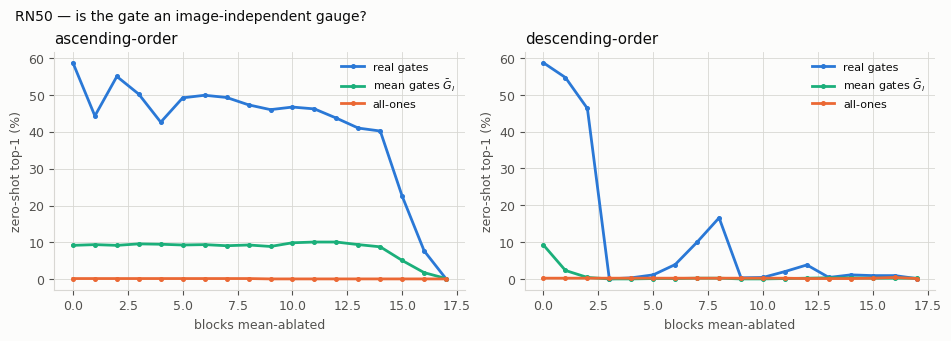

order         # blocks ablated    real gates    mean gates $\bar G_l$    all-ones
----------  ------------------  ------------  -----------------------  ----------
ascending                    0          58.7                      9.2         0.2
ascending                    4          42.6                      9.5         0.2
ascending                    8          47.3                      9.3         0.2
ascending                   12          43.7                     10.1         0.1
ascending                   17           0.1                      0.2         0.1
descending                   0          58.7                      9.2         0.2
descending                   4           0.3                      0           0.2
descending                   8          16.6                      0.2         0.2
descending                  12           3.8                      0.2         0.1
descending                  17           0.1                      0.2         0.1


  block k    ||mean gated|| / ||E[M]||    ||E[G]E[F]|| / ||E[M]||    rel. gap = Cov     cos
---------  ---------------------------  -------------------------  ----------------  ------
        0                       0.9191                     0.2476             0.836   0.694
        1                       0.9413                     0.2448             0.851   0.659
        2                       0.5328                     0.1565             0.801   0.757
        3                       0.6734                     0.2113             0.762   0.826
        4                       1.3901                     0.4785             0.729   0.853
        5                       0.2888                     0.1137             0.71    0.826
        6                       0.3025                     0.1123             0.747   0.781
        7                       0.2322                     0.1108             0.704   0.766
        8                       1.1552                     0.4144             0.

In [34]:
# --- (7b) block-wise mean ablation under the folded gauge, and Cov(G_k, F_k) -------------------
def as_run_g(comp):
    """[B, L+2, out] (L+1 blocks + c_pos) -> the run dict `ablation_curve` consumes."""
    return {"exact": {"attn": comp[:, :N_BLK, None, :], "mlp": comp[:, N_BLK:],
                      "bias": torch.zeros(comp.shape[0], OUT, device=DEVICE)},
            "emb": comp.sum(1), "labels": lab_g}


g_curves, g_base = {}, {}
for tag, comp in GAUGE.items():
    r = as_run_g(comp)
    g_base[tag] = top1(r["emb"], CLS_RN, lab_g)
    for order in ("ascending", "descending"):
        g_curves[(tag, order)] = ablation_curve(r, "exact", block_groups(N_BLK, 1, order), CLS_RN)

GC = {"real gates": "#2a78d6", "mean gates $\\bar G_l$": "#1baf7a", "all-ones": "#eb6834"}
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3), constrained_layout=True)
for ax, order in zip(axes, ("ascending", "descending")):
    for tag, col in GC.items():
        ns, acc, _ = g_curves[(tag, order)]
        ax.plot(np.arange(len(acc)), acc, color=col, marker="o", ms=2.6, label=tag)
    ax.set_xlabel("blocks mean-ablated"); ax.set_ylabel("zero-shot top-1 (%)")
    ax.set_title(f"{order}-order", loc="left", color=INK); ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"{RN_NAME} — is the gate an image-independent gauge?", x=0.01, ha="left",
             fontsize=10, color=INK)
plt.show()

rows = []
for order in ("ascending", "descending"):
    for i in (0, 4, 8, 12, N_BLK):
        rows.append([order, i] + [f"{g_curves[(t, order)][1][i]:.2f}" for t in GC])
print(tabulate(rows, headers=["order", "# blocks ablated"] + list(GC)))

# Cov(G_k, F_k): the honest mean of the gated write vs the factorized bar G_k . bar F_k.
# Both are pooled with the SAME per-image real attention and averaged, so pooling cancels out.
@torch.no_grad()
def factorized_mean_components(visual, means, pmean):
    """bar G_k . bar F_k propagated to the final feature map. Image-independent."""
    with rprs._full_fp32():
        contribs, idx = [means[0][None]], 1
        for layer in RN_STAGES:
            for block in layer:
                p, ds = pmean[idx - 1][None], block.downsample
                if ds is not None:
                    contribs = [p * rprs._downsample_linear_only(ds, t) for t in contribs]
                else:
                    contribs = [p * t for t in contribs]
                contribs.append(p * means[idx][None])
                idx += 1
    return contribs


FAC = factorized_mean_components(visual, means_raw, P_MEAN)
fac_acc, n_acc = torch.zeros(N_BLK, OUT, device=DEVICE), 0
for b0 in range(0, len(NM_IDX), BS):
    im = NM_IMGS[b0:b0 + BS]
    with rprs._full_fp32():
        Zr = visual.stem(im)
        for layer in RN_STAGES:
            for block in layer:
                Zr = block(Zr)
    c_lh, _, _ = rprs.attnpool_split(visual.attnpool, [t.expand(im.shape[0], -1, -1, -1) for t in FAC],
                                     Zr, check=False, vision_proj=True)
    fac_acc += c_lh.sum(2).sum(0); n_acc += im.shape[0]
    del c_lh
c_fac = fac_acc / n_acc                                  # factorized  E[G] E[F], pooled
rel = (c_fac - c_mean).norm(dim=-1) / c_mean.norm(dim=-1)
cs = torch.nn.functional.cosine_similarity(c_fac, c_mean, dim=-1)
Mbar = M_true.mean(0).norm()
print(tabulate([[k, f"{c_mean[k].norm()/Mbar:.4f}", f"{c_fac[k].norm()/Mbar:.4f}",
                 f"{rel[k]:.3f}", f"{cs[k]:+.3f}"] for k in range(N_BLK)],
               headers=["block k", "||mean gated|| / ||E[M]||", "||E[G]E[F]|| / ||E[M]||",
                        "rel. gap = Cov", "cos"]))
print(f"\nCov(G_k, F_k) as a relative gap: mean {rel.mean():.3f}, median {rel.median():.3f}, "
      f"max {rel.max():.3f}   |   mean cos {cs.mean():+.3f}")
torch.cuda.empty_cache()

---
## Conclusions

### Part 1 — the objection is correct, the fix is exact, and it changes nothing measurable

**The algebra is confirmed, precisely.** The uniform split does inject a shared term into every head:
$\delta_k$ lies in $\mathrm{span}\{P\gamma, P\beta\}$ with **100.0000%** of its image-varying energy in
that 2-D subspace, for every head of both models. (It is 2-D rather than 1-D only because dividing by
$\|M(I)\|$ makes the $P\beta$ share image-dependent too.) So the theoretical claim — a component
belonging to no head in particular is present in every head's matrix — holds exactly.

**But it is almost entirely the constant part, which centering already removes.** This is the crux:

| | ViT-B-16 | ViT-L-14 |
|---|---|---|
| $\|\delta\|/\|\tilde c\|$, total | 8.8% | 5.0% |
| $\|\delta\|/\|\tilde c\|$, image-varying only | **1.5%** | **0.8%** |
| share of a head's cross-image variance | **0.032%** | **0.008%** |
| median $\|\cos(\mathrm{PC}_1, P\gamma)\|$, uniform split | 0.050 | 0.034 |
| median $\|\cos(\mathrm{PC}_1, P\gamma)\|$, centering fold | 0.047 | 0.030 |

The smeared offset is 5–9% of a head's norm, which sounds alarming — but the part with genuine
cross-image variance is under 2%, and it accounts for **well under a tenth of a percent** of what a
head actually varies by across images. TextSpan (Eq. 7) and PCLens both mean-center before selecting
directions, and that step removes the constant $P\beta$ share, i.e. almost all of $\delta$. The
head PC1 directions are essentially unmoved (0.050 → 0.047, 0.034 → 0.030), so the shared direction
is **not** contaminating the bases those methods select on. The proposed mechanism for "not all heads
have coherent roles" and for repeated descriptions across heads is therefore not supported here.

**Mean-ablation is unaffected.** Across all 12 sweeps (2 models x 3 component families x 2 orders),
the largest accuracy gap between the two conventions is **0.14 points**, against a binomial standard
error of **0.65 / 0.62 points** at N = 5000. Every AUC ratio sits in [0.999, 1.001]. The two curves
are indistinguishable; nothing here is evidence either way about which convention is "better" for
ablation, because there is no measurable difference to attribute.

**Verdict.** In the terms of the proposed experiment: (a) is small once you separate the constant
from the varying part, and (b)–(d) do not move. The uniform split was an **unforced approximation
that happens to be harmless** — it should have been justified in the paper rather than asserted, and
the exact fold ($\tilde P = PDC$ with $P\beta$ as a standalone bias) costs nothing and removes the
question, but no published result rests on it. That is a clean negative result, and worth stating
as such rather than leaving the objection open.

Two caveats this notebook does **not** reach: freezing $\sigma$ is a genuinely lossy linearization
(unaddressed by either convention), and the `attn.out_proj` bias is still split $b_{\rm out}/H$
across heads under both — deliberately, so it is not a confound, but it is the same species of
unjustified split.

### Part 2a — ResNet block ablation and geometry: the components do *not* behave like the ViT's

> **Read Part 2c first.** The audit below finds a mean NMAE of **144%** between this decomposition's
> predicted ablation effect and the actual one. The curves in this section are *decomposition*
> ablations and should not be read as causal statements about the network.

RN50 baseline is **58.88%** (N = 5000, binomial SE 0.70 pts). Block-wise mean ablation:

| # blocks ablated | ascending (stem first) | descending (last first) |
|---|---|---|
| 1 | 44.70 (−14.18) | 53.78 (−5.10) |
| 4 | 42.24 (−16.64) | **0.16** (−58.72) |
| 8 | **48.50** (−10.38) | **16.28** (−42.60) |
| 12 | 42.56 (−16.32) | 3.88 (−55.00) |
| 17 (all) | 0.10 | 0.10 |

**Both curves are non-monotone**, and badly so — ablating *more* blocks can *recover* accuracy (descending:
4 blocks → 0.16%, but 8 blocks → 16.28%; ascending: 4 → 42.24%, but 8 → 48.50%). This is the opposite
of the ViT, where early-layer ablation was nearly free and the curves fell monotonically. Two further
contrasts: ablating the **stem alone** already costs 14 points, and no prefix of the ResNet is
"safely ablatable" the way ViT layers 0–5 were.

The geometry cell says why:

- **The components massively cancel.** The block relative norms sum to **11.44** while $\|M\|=1$.
  The final embedding is a small residue of large opposing writes, so mean-ablating any subset
  perturbs a delicate cancellation rather than gently removing a summand.
- **Norm does not track usefulness.** Block 14 is the largest component (rel norm **2.14**) yet sits
  essentially orthogonal to the output ($\cos = 0.004$). Per-head cosines span only
  $[-0.14, +0.18]$ across every block.
- **`c_pos` is not negligible.** The content-free positional/value-bias term has rel norm **1.78** —
  longer than the embedding itself — at $\cos = +0.463$, the single most output-aligned component.

Practical consequence: for CLIP-ResNet, "which block matters" cannot be read off component norms,
and mean-ablation is not a mild intervention. Any head/block attribution built on this decomposition
should report the cancellation ratio alongside it. (Note these ablations are *decomposition*
ablations — downstream blocks are not recomputed — which is exactly why cancellation dominates;
a causal re-run would behave differently and is a separate experiment.)

### Part 2c — auditing the frozen-ReLU decomposition: it does not survive contact with the network

**1. The gates destroy ~90% of every block's write.** Mean global gate survival
$\|G_lF_l\|/\|G_l^{\text{no-gate}}F_l\|$ is **0.101** across blocks: **1.5%** for the stem and
early blocks, rising to only 27% for the last. Single-gate openness is 0.22–0.73 and the literal
within-stage $\prod_j D_j$ falls to 0.10–0.73. So an early block's attribution is the residue of a
98.5% annihilation — the objection is quantitatively correct.

**2. The per-image-map objection is *partly* weakened, not dismissed.** Mean pairwise Jaccard of the
gate supports across images is **0.613** — but the gates are 22–73% *dense*, and density-matched
independent masks would already agree at **0.409**. The real signal is the excess, **+0.10 to +0.36**
(mean +0.20). There is a substantial always-on core, and also a genuine per-image component; $G_k$ is
neither a fixed map nor a fresh one per image.

**3. Everything cancels — including the ViTs.** Cancellation ratio $\sum_k\|c_k\|/\|\sum_k c_k\|$:

| model | granularity | ratio |
|---|---|---|
| RN50 | block (+`c_pos`), embedding space | **13.2** |
| RN50 | block x head (+`c_pos`) | **53.3** |
| RN50 | block, feature-map space (pre-pool) | **14.5** |
| ViT-B-16 | head + MLP (fold) | **8.9** |
| ViT-L-14 | head + MLP (fold) | **11.4** |

This is the finding with the widest blast radius. The ResNet per-head view is a sum of 545 terms whose
lengths total 53x the output. But the **ViT** decomposition — the one the entire TextSpan/PCLens line
of work is built on — also cancels 9–11x. Individual summands are largely mutually-cancelling mass in
*both* architectures, however the nonlinearity is handled.

**4. The frozen-gate direct effect is not the real effect: NMAE ~144%.** Comparing the decomposition's
predicted mean-ablation delta against **re-running the real network** with that block's write replaced
by its dataset mean: mean NMAE **143.6%**, median **129.9%** — versus the ~49% reported for GPT-2
attention heads. Worse, $\cos(\text{direct}, \text{actual})$ is $\approx 0$ for 15 of 17 blocks
(range $-0.16$ to $+0.08$; only the final two blocks reach $\approx 0.57$). An NMAE above 100% means
the error exceeds the signal: **the frozen-gate prediction is close to uninformative about what
ablating a block actually does.** Concretely, the decomposition predicts ablating the stem leaves
42.97% top-1; the truth is 0.00%. It predicts block 14 leaves 1.17%; the truth is 35.55%.

**5. Gating and ablation damage are *not* the same phenomenon.** Survival vs. marginal
single-block actual damage correlates at Pearson **−0.25**, Spearman **−0.27** — weak, and the wrong
sign. Blocks whose writes survive *least* (the stem, 1.5%) do the *most* damage when ablated. So the
masking cannot be read as a proxy for importance.

**The all-ones control settles it.** Forcing every $M_l$ to all-ones drops zero-shot from **58.70%
to 0.20%** — chance — *before any ablation*. The masking is not a correction to the computation, it
essentially *is* the computation. And under ablation the control barely moves (cosine 0.89–0.999)
while the real decomposition collapses (0.39–0.63): a gap of up to **−0.61**. That gap is the masking
contribution, and it is nearly the whole effect.

**Taken together:** for CLIP-ResNet the frozen-ReLU decomposition is *exact as an identity* and
*close to meaningless as an attribution*. Any head/block claim built on it needs the NMAE and the
cancellation ratio reported alongside, or an actual-ablation check. The cancellation numbers say the
ViT side deserves the same scrutiny even though its decomposition has no frozen gates.

### Part 2d — does $(k,n)$ granularity change the ablation? No, provably

Max difference between block-granularity and $(k,n)$-granularity curves over **both** full sweeps:
**0.1 points** — one image in 1000, consistent with the fp32 cross-implementation agreement of
$2.9\times10^{-3}$ relative. Mean-ablation is linear, so
$\sum_n \overline{\boldsymbol r^{n,k}} = \bar{\boldsymbol r}^k$ and any regrouping that ablates
the same set is the identical embedding. Verified directly:
$\sum_n \overline{\boldsymbol r^{n,k}}$ vs $\overline{\boldsymbol r^k}$ agrees to $5.8\times10^{-6}$.

Granularity only buys something when it lets you name a set you could not name before. Ablating just
the **top-10% highest-norm neurons** of every block leaves **34.4%** top-1 where full block ablation
leaves **0.1%** — so ~10% of channels carry much, but far from all, of each block's effect.

### Part 2b — is this already our decomposition? Mostly yes

The block-head granularity is **already** the decomposition in
`utils/models/resnet_prs.py`, and it is already what sits in `output_dir` as
`[N, L+1, H, out_dim]`. The four-index form adds the neuron and token indices; both were being
summed out inside `head_value`. Verified here: the full four-index sum reproduces `visual(I)`, and
collapsing $n,i$ reproduces `c_lh` exactly. The full granularity is a contraction-only object
(materializing $\boldsymbol r^{n,h,k}_i$ would need terabytes per image); the useful new middle rung is
$(k,h,i)$, which is cheap and gives per-block spatial attribution per head.

### Part 2h — zero vs mean ablation

**ViT.** Zero ablation costs 1.6-6.9 pts more than mean ablation at the sweep midpoint (largest on
MLPs and heads ablated early). The uniform-split vs fold difference stays inside the binomial SE
(0.65 pts B-16, 0.62 pts L-14) under *both* references, so Part 1's negative result is not an
artifact of the mean reference.

**RN50.** Decomposition-space zero ablation is harsher than mean (ascending, 12 blocks: 20.70% vs
42.19%), but the decomposition-to-actual gap is larger than the gap between references:
33.8 pts (mean) / 24.7 pts (zero) ascending, 4.9 / 3.5 pts descending. Under actual re-runs the
ascending sweep is at 0% after the stem alone for both references (gap exactly 0.00 pts);
descending differs by 1.11 pts. Switching reference does not make the ResNet decomposition causal.